# ADHD Behavioral Modeling: Drift Diffusion & Latent State Analysis




## Section 0 — Imports & Configuration

In [1]:
import warnings, logging, os, sys
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import mannwhitneyu, pearsonr, shapiro, levene, spearmanr

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      cross_validate, permutation_test_score)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.patches import Patch

try:
    from pykalman import KalmanFilter
    KALMAN_AVAILABLE = True
except ImportError:
    KALMAN_AVAILABLE = False
    print("WARNING: pykalman not available")

try:
    import pyddm
    from pyddm import Model, Sample, Fittable
    from pyddm.models import (DriftConstant, NoiseConstant, BoundConstant,
                               OverlayNonDecision, OverlayChain,
                               OverlayUniformMixture, LossRobustLikelihood)
    from pyddm.functions import fit_adjust_model
    DDM_AVAILABLE = True
    print(f"pyddm {pyddm.__version__}")
except ImportError:
    DDM_AVAILABLE = False
    print("WARNING: pyddm not available — Section 5 skipped.")

#  Global config 
SEED       = 42
N_BOOT     = 2000   # bootstrap reps for Cohen's d CI
N_PERMUTE  = 200    # permutation reps (200 is enough for p<0.05 resolution)  # FIX: was 500, too slow
CV_FOLDS   = 5
FDR_METHOD = "fdr_bh"

np.random.seed(SEED)

PALETTE     = {"ADHD": "#E63946", "Control": "#457B9D"}
GROUP_ORDER = ["Control", "ADHD"]
sns.set_theme(style="whitegrid", font_scale=1.1)
matplotlib.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Config done. SEED =", SEED)


pyddm 0.9.0
Config done. SEED = 42


## Section 1 — Data Loading & Preprocessing

In [2]:
def load_and_merge(trial_path="long_CPT.csv", meta_path="patient_info.csv"):
    df = pd.read_csv(trial_path)
    df.columns = df.columns.str.strip()
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    try:
        meta = pd.read_csv(meta_path, sep=";")
        meta.columns = meta.columns.str.strip().str.replace("\ufeff", "", regex=False)
        keep = [c for c in ["ID","ADHD","AGE","SEX","ASRS","WURS","MADRS"] if c in meta.columns]
        df = df.merge(meta[keep], left_on="subject", right_on="ID", how="left")
        print(f"Merged: {keep}")
    except FileNotFoundError:
        print("WARNING: patient_info.csv not found")
    return df


def preprocess_cpt(df):
    df = df.copy()
    df["rt"] = df["rt"].replace(-1, np.nan)
    df.loc[df["rt"] < 150,  "rt"] = np.nan
    df.loc[df["rt"] > 2000, "rt"] = np.nan
    df["rt_sec"] = df["rt"] / 1000.0
    if "correct" not in df.columns:
        is_go = df["stimulus"] != 0
        df["correct"] = (
            (is_go  & (df["responded"] == 1)) |
            (~is_go & (df["responded"] == 0))
        ).astype(int)
    df = df.dropna(subset=["stimulus","responded"])
    df["group"] = df["ADHD"].map({1:"ADHD", 0:"Control"})
    return df


raw_df = load_and_merge()
cpt_df = preprocess_cpt(raw_df)
print(f"Shape: {cpt_df.shape}")
print(f"Subjects: {cpt_df['subject'].nunique()}  "
      f"ADHD={cpt_df[cpt_df['ADHD']==1]['subject'].nunique()}  "
      f"Control={cpt_df[cpt_df['ADHD']==0]['subject'].nunique()}")


Merged: ['ID', 'ADHD', 'AGE', 'SEX', 'ASRS', 'WURS', 'MADRS']
Shape: (35640, 15)
Subjects: 99  ADHD=50  Control=49


In [3]:
cpt_df

,subject,trial,stimulus,rt,responded,ID,ADHD,AGE,SEX,ASRS,WURS,MADRS,rt_sec,correct,group
0,2.0,1,11.0,NaN,0,2,1,4,0,62.0,83.0,11.0,NaN,0,ADHD
1,2.0,2,13.0,469.0,1,2,1,4,0,62.0,83.0,11.0,0.469,1,ADHD
2,2.0,3,7.0,343.0,1,2,1,4,0,62.0,83.0,11.0,0.343,1,ADHD
3,2.0,4,15.0,275.0,1,2,1,4,0,62.0,83.0,11.0,0.275,1,ADHD
4,2.0,5,0.0,295.0,1,2,1,4,0,62.0,83.0,11.0,0.295,0,ADHD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35635,108.0,356,6.0,282.0,1,108,1,3,1,51.0,65.0,NaN,0.282,1,ADHD
35636,108.0,357,2.0,403.0,1,108,1,3,1,51.0,65.0,NaN,0.403,1,ADHD
35637,108.0,358,7.0,336.0,1,108,1,3,1,51.0,65.0,NaN,0.336,1,ADHD
35638,108.0,359,5.0,320.0,1,108,1,3,1,51.0,65.0,NaN,0.320,1,ADHD


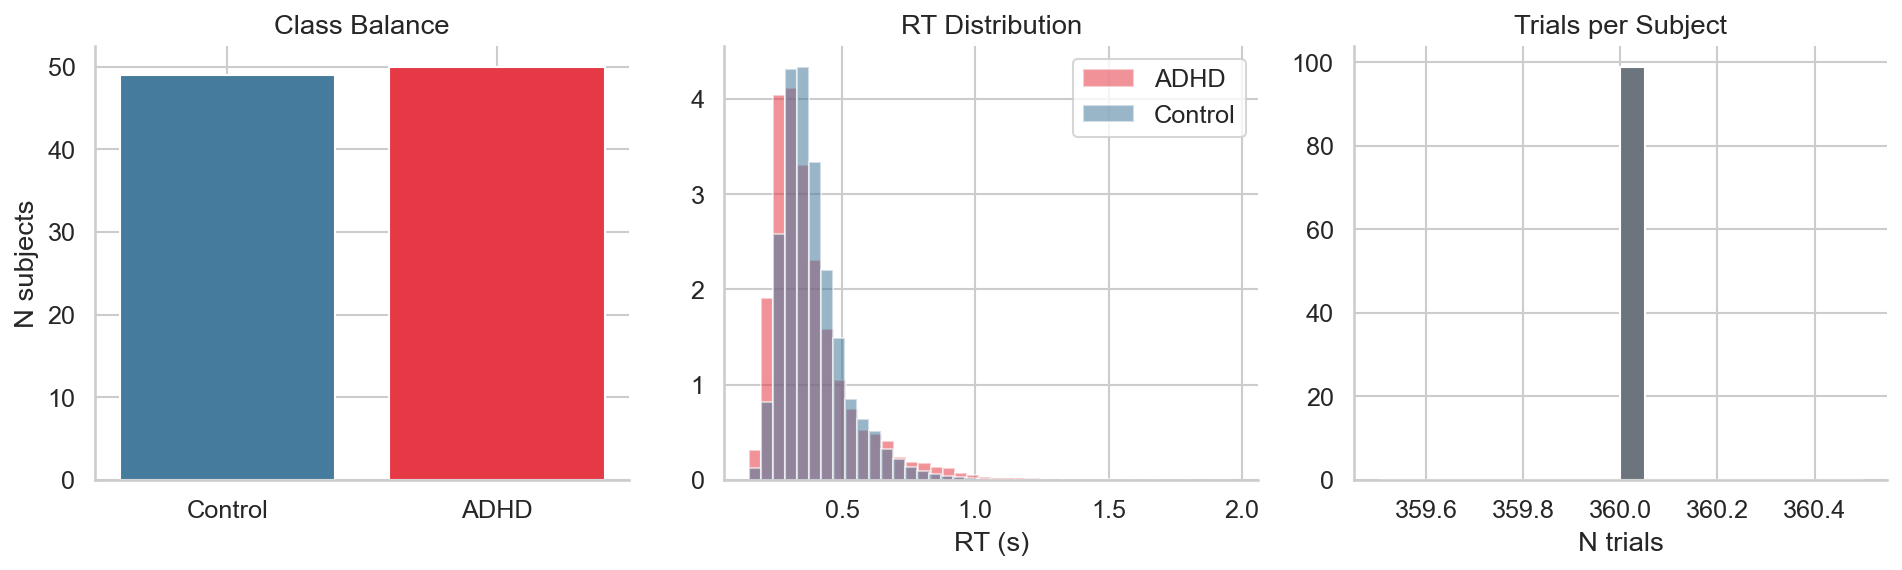

In [4]:
# Sanity-check plots
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

grp_counts = cpt_df.groupby("subject")["ADHD"].first().value_counts()
axes[0].bar(["Control","ADHD"], [grp_counts.get(0,0), grp_counts.get(1,0)],
            color=[PALETTE["Control"], PALETTE["ADHD"]], edgecolor="white")
axes[0].set_title("Class Balance"); axes[0].set_ylabel("N subjects")

for grp, col in PALETTE.items():
    sub = cpt_df[(cpt_df["group"]==grp) & cpt_df["rt_sec"].notna()]["rt_sec"]
    axes[1].hist(sub, bins=40, alpha=0.55, color=col, label=grp, density=True)
axes[1].set_title("RT Distribution"); axes[1].set_xlabel("RT (s)"); axes[1].legend()

axes[2].hist(cpt_df.groupby("subject").size(), bins=20, color="#6C757D", edgecolor="white")
axes[2].set_title("Trials per Subject"); axes[2].set_xlabel("N trials")

plt.tight_layout(); plt.show()


## Section 2 — Behavioral Analysis
**Upgrades:** Shapiro-Wilk + Levene assumption checks · Bootstrap 95% CI on Cohen's d


In [5]:
from scipy.stats import norm

def compute_subject_stats(df):
    records = []

    for sid, s in df.groupby("subject"):

        # Trial types
        go = s[s["stimulus"] != 0]
        nogo = s[s["stimulus"] == 0]

        # --------------------------------------------------
        # KEEP YOUR EXISTING RT CALCULATION
        # --------------------------------------------------
        rt_valid = go[go["rt_sec"].notna()]

        rt_mean = rt_valid["rt_sec"].mean()
        rt_std = rt_valid["rt_sec"].std()

        # --------------------------------------------------
        # NEW: OMISSIONS
        # No response on a Go trial
        # --------------------------------------------------
        n_omissions = (go["responded"] == 0).sum()

        omission_rate = (
            n_omissions / len(go)
            if len(go) > 0 else np.nan
        )

        # --------------------------------------------------
        # NEW: COMMISSIONS
        # Response on a No-Go trial
        # --------------------------------------------------
        n_commissions = (nogo["responded"] == 1).sum()

        commission_rate = (
            n_commissions / len(nogo)
            if len(nogo) > 0 else np.nan
        )

        # --------------------------------------------------
        # NEW: d-prime
        # --------------------------------------------------
        hits = (go["responded"] == 1).sum()
        false_alarms = (nogo["responded"] == 1).sum()

        n_go = len(go)
        n_nogo = len(nogo)

        if n_go > 0 and n_nogo > 0:

            # Log-linear correction
            hit_rate = (hits + 0.5) / (n_go + 1)
            fa_rate = (false_alarms + 0.5) / (n_nogo + 1)

            d_prime = (
                norm.ppf(hit_rate)
                - norm.ppf(fa_rate)
            )

        else:
            hit_rate = np.nan
            fa_rate = np.nan
            d_prime = np.nan

        # Existing metrics
        accuracy = s["correct"].mean()
        response_rate = s["responded"].mean()

        records.append({
            "subject": sid,

            # Existing
            "rt_mean": rt_mean,
            "rt_std": rt_std,
            "accuracy": accuracy,
            "response_rate": response_rate,

            # New
            "omissions": n_omissions,
            "omission_rate": omission_rate,
            "commissions": n_commissions,
            "commission_rate": commission_rate,
            "hit_rate": hit_rate,
            "false_alarm_rate": fa_rate,
            "d_prime": d_prime,

            "n_trials": len(s),
            "n_go": n_go,
            "n_nogo": n_nogo,
            "ADHD": s["ADHD"].iloc[0]
        })

    out = pd.DataFrame(records)

    out["group"] = out["ADHD"].map({
        1: "ADHD",
        0: "Control"
    })

    clinical = [
        c for c in
        ["ASRS", "WURS", "MADRS", "AGE", "SEX"]
        if c in df.columns
    ]

    if clinical:
        clin = (
            df.groupby("subject")[clinical]
            .first()
            .reset_index()
        )

        out = out.merge(
            clin,
            on="subject",
            how="left"
        )

    return out


# Recompute subject-level data
subj_df = compute_subject_stats(cpt_df)

print(f"Subject table: {subj_df.shape}")

subj_df.head()

Subject table: (99, 22)


,subject,rt_mean,rt_std,accuracy,response_rate,omissions,omission_rate,commissions,commission_rate,hit_rate,...,n_trials,n_go,n_nogo,ADHD,group,ASRS,WURS,MADRS,AGE,SEX
0,2.0,0.383821,0.126803,0.905556,0.961111,6,0.018519,28,0.777778,0.980000,...,360,324,36,1,ADHD,62.0,83.0,11.0,4,0
1,3.0,0.327861,0.090058,0.888889,0.944444,12,0.037037,28,0.777778,0.961538,...,360,324,36,1,ADHD,60.0,72.0,6.0,2,1
2,4.0,0.474341,0.150806,0.891667,0.919444,16,0.049383,23,0.638889,0.949231,...,360,324,36,1,ADHD,46.0,82.0,19.0,3,1
3,5.0,0.344106,0.098351,0.883333,0.961111,10,0.030864,32,0.888889,0.967692,...,360,324,36,1,ADHD,56.0,60.0,28.0,1,1
4,7.0,0.385437,0.093294,0.966667,0.927778,1,0.003086,11,0.305556,0.995385,...,360,324,36,0,Control,21.0,31.0,2.0,3,0


In [6]:
subj_df['AGE'].value_counts().sort_index()

AGE
1    27
2    28
3    28
4    16
Name: count, dtype: int64

In [7]:
subj_df

,subject,rt_mean,rt_std,accuracy,response_rate,omissions,omission_rate,commissions,commission_rate,hit_rate,...,n_trials,n_go,n_nogo,ADHD,group,ASRS,WURS,MADRS,AGE,SEX
0,2.0,0.383821,0.126803,0.905556,0.961111,6,0.018519,28,0.777778,0.980000,...,360,324,36,1,ADHD,62.0,83.0,11.0,4,0
1,3.0,0.327861,0.090058,0.888889,0.944444,12,0.037037,28,0.777778,0.961538,...,360,324,36,1,ADHD,60.0,72.0,6.0,2,1
2,4.0,0.474341,0.150806,0.891667,0.919444,16,0.049383,23,0.638889,0.949231,...,360,324,36,1,ADHD,46.0,82.0,19.0,3,1
3,5.0,0.344106,0.098351,0.883333,0.961111,10,0.030864,32,0.888889,0.967692,...,360,324,36,1,ADHD,56.0,60.0,28.0,1,1
4,7.0,0.385437,0.093294,0.966667,0.927778,1,0.003086,11,0.305556,0.995385,...,360,324,36,0,Control,21.0,31.0,2.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,103.0,0.446080,0.105694,0.972222,0.922222,1,0.003086,9,0.250000,0.995385,...,360,324,36,0,Control,48.0,49.0,22.0,4,1
95,104.0,0.363339,0.129541,0.947222,0.941667,2,0.006173,17,0.472222,0.992308,...,360,324,36,0,Control,49.0,32.0,10.0,2,0
96,105.0,0.360969,0.088383,0.950000,0.927778,4,0.012346,14,0.388889,0.986154,...,360,324,36,0,Control,22.0,35.0,20.0,4,1
97,106.0,0.361073,0.157720,0.919444,0.941667,7,0.021605,22,0.611111,0.976923,...,360,324,36,0,Control,50.0,54.0,NaN,3,0


In [8]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency

df = subj_df.copy()

adhd = df[df["ADHD"] == 1]
control = df[df["ADHD"] == 0]

def cohens_d(x1, x2):
    x1 = x1.dropna()
    x2 = x2.dropna()

    pooled_sd = np.sqrt(
        ((len(x1)-1)*x1.var(ddof=1) +
         (len(x2)-1)*x2.var(ddof=1))
        / (len(x1)+len(x2)-2)
    )

    return (x1.mean() - x2.mean()) / pooled_sd


rows = []

# --------------------------------------------------
# Continuous Variables
# --------------------------------------------------

continuous_vars = [
    ("AGE", "Age"),
    ("ASRS", "ASRS"),
    ("WURS", "WURS"),
    ("MADRS", "MADRS"),
    ("rt_mean", "RT Mean (s)"),
    ("rt_std", "RT Variability (s)"),
    ("accuracy", "Accuracy"),
    ("response_rate", "Response Rate")
]

for col, label in continuous_vars:

    if col not in df.columns:
        continue

    t, p = ttest_ind(
        adhd[col].dropna(),
        control[col].dropna(),
        equal_var=False
    )

    d = cohens_d(
        adhd[col],
        control[col]
    )

    rows.append({
        "Variable": label,
        "Full Sample":
            f"{df[col].mean():.2f} ({df[col].std():.2f})",
        "ADHD":
            f"{adhd[col].mean():.2f} ({adhd[col].std():.2f})",
        "Control":
            f"{control[col].mean():.2f} ({control[col].std():.2f})",
        "Statistic":
            f"t = {t:.2f}",
        "p":
            f"{p:.4f}",
        "Effect":
            f"d = {d:.2f}"
    })

# --------------------------------------------------
# SEX
# --------------------------------------------------

if "SEX" in df.columns:

    sex_tab = pd.crosstab(df["SEX"], df["ADHD"])

    chi2, p, dof, exp = chi2_contingency(sex_tab)

    phi = np.sqrt(chi2 / sex_tab.values.sum())

    rows.append({
        "Variable": "Sex",
        "Full Sample": "",
        "ADHD": "",
        "Control": "",
        "Statistic": f"χ²({dof})={chi2:.2f}",
        "p": f"{p:.4f}",
        "Effect": f"φ={phi:.2f}"
    })

    for sex in sex_tab.index:

        full_n = (df["SEX"] == sex).sum()
        adhd_n = (adhd["SEX"] == sex).sum()
        control_n = (control["SEX"] == sex).sum()

        rows.append({
            "Variable": f"   {sex}",
            "Full Sample":
                f"{full_n} ({100*full_n/len(df):.1f}%)",
            "ADHD":
                f"{adhd_n} ({100*adhd_n/len(adhd):.1f}%)",
            "Control":
                f"{control_n} ({100*control_n/len(control):.1f}%)",
            "Statistic": "",
            "p": "",
            "Effect": ""
        })

table1 = pd.DataFrame(rows)

print(table1)

table1.to_excel(
    "Table1_ADHD_Demographics.xlsx",
    index=False
)

table1.to_csv(
    "Table1_ADHD_Demographics.csv",
    index=False
)

print("\nSaved successfully.")

              Variable    Full Sample           ADHD        Control  \
0                  Age    2.33 (1.05)    2.38 (1.03)    2.29 (1.08)   
1                 ASRS  40.29 (14.12)  47.35 (10.85)  32.59 (13.31)   
2                 WURS  41.16 (21.30)  52.78 (19.20)  28.51 (15.59)   
3                MADRS   13.43 (7.92)   12.95 (7.35)   13.93 (8.53)   
4          RT Mean (s)    0.39 (0.09)    0.39 (0.10)    0.39 (0.07)   
5   RT Variability (s)    0.11 (0.05)    0.13 (0.06)    0.10 (0.04)   
6             Accuracy    0.92 (0.13)    0.91 (0.05)    0.92 (0.17)   
7        Response Rate    0.91 (0.14)    0.92 (0.05)    0.89 (0.19)   
8                  Sex                                                
9                    0     48 (48.5%)     22 (44.0%)     26 (53.1%)   
10                   1     51 (51.5%)     28 (56.0%)     23 (46.9%)   

     Statistic       p     Effect  
0     t = 0.44  0.6575   d = 0.09  
1     t = 5.80  0.0000   d = 1.22  
2     t = 6.75  0.0000   d = 1.38  
3  

In [9]:
age_tab = pd.crosstab(subj_df['AGE'], subj_df['ADHD'])
print(age_tab)

ADHD   0   1
AGE         
1     15  12
2     13  15
3     13  15
4      8   8


In [10]:
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, _ = chi2_contingency(age_tab)
phi = np.sqrt(chi2 / age_tab.values.sum())

print("chi2 =", chi2)
print("p =", p)
print("phi =", phi)

chi2 = 0.6090087463556851
p = 0.8943669654142421
phi = 0.0784321585737781


In [11]:
# ============================================================
# Statistical utility functions
# ============================================================

def cohens_d(a, b):
    na, nb = len(a), len(b)

    pooled = np.sqrt(
        ((na - 1) * np.var(a, ddof=1) +
         (nb - 1) * np.var(b, ddof=1))
        / (na + nb - 2)
    )

    return (
        (np.mean(a) - np.mean(b)) / pooled
        if pooled > 0 else np.nan
    )


def rank_biserial_from_u(u, n1, n2):
    """
    Positive value = higher in ADHD
    Negative value = lower in ADHD
    """
    return (2 * u) / (n1 * n2) - 1


def assumption_check(a, b, label):

    _, p_a = shapiro(a)
    _, p_b = shapiro(b)
    _, p_lev = levene(a, b)

    normal = (p_a > 0.05) and (p_b > 0.05)
    eq_var = p_lev > 0.05

    if normal and eq_var:
        recommended = "Independent t-test"
    else:
        recommended = "Mann-Whitney U"

    return {
        "Variable": label,
        "SW p (ADHD)": f"{p_a:.3f}",
        "SW p (Ctrl)": f"{p_b:.3f}",
        "Normal?": "Yes" if normal else "No",
        "Levene p": f"{p_lev:.3f}",
        "Equal var?": "Yes" if eq_var else "No",
        "Recommended": recommended
    }


def compare_groups(df, var, label):

    adhd = (
        df.loc[df["ADHD"] == 1, var]
        .dropna()
        .values
    )

    ctrl = (
        df.loc[df["ADHD"] == 0, var]
        .dropna()
        .values
    )

    # Assumption tests
    _, p_adhd = shapiro(adhd)
    _, p_ctrl = shapiro(ctrl)
    _, p_lev = levene(adhd, ctrl)

    normal = (p_adhd > 0.05) and (p_ctrl > 0.05)
    equal_var = p_lev > 0.05

    # --------------------------------------------------------
    # Parametric case
    # --------------------------------------------------------
    if normal and equal_var:

        stat, p = ttest_ind(
            adhd,
            ctrl,
            equal_var=True
        )

        effect = cohens_d(adhd, ctrl)

        test_name = "Independent t-test"
        stat_name = "t"
        effect_name = "Cohen's d"

    # --------------------------------------------------------
    # Non-parametric case
    # --------------------------------------------------------
    else:

        stat, p = mannwhitneyu(
            adhd,
            ctrl,
            alternative="two-sided"
        )

        effect = rank_biserial_from_u(
            stat,
            len(adhd),
            len(ctrl)
        )

        test_name = "Mann-Whitney U"
        stat_name = "U"
        effect_name = "Rank-biserial r"

    return {
        "Variable": label,

        "ADHD mean (SD)":
            f"{np.mean(adhd):.3f} ({np.std(adhd, ddof=1):.3f})",

        "Control mean (SD)":
            f"{np.mean(ctrl):.3f} ({np.std(ctrl, ddof=1):.3f})",

        "Test": test_name,

        "Statistic":
            f"{stat_name} = {stat:.3f}",

        "p-value": f"{p:.4f}",

        "Effect size":
            f"{effect_name} = {effect:.3f}",

        "Sig":
            "***" if p < 0.001
            else "**" if p < 0.01
            else "*" if p < 0.05
            else "ns"
    }

In [12]:
METRICS = [
    ("rt_mean",         "HRT (s)"),
    ("rt_std",          "HRT SD (s)"),
    ("omission_rate",   "Omission Error Rate"),
    ("commission_rate", "Commission Error Rate"),
    ("d_prime",         "Detectability (d′)")
]

# Assumption checks
assump_rows = [
    assumption_check(
        subj_df.loc[subj_df["ADHD"]==1, var].dropna().values,
        subj_df.loc[subj_df["ADHD"]==0, var].dropna().values, lbl
    ) for var, lbl in METRICS
]
print("=== Table A: Assumption Checks ===")
print(pd.DataFrame(assump_rows).to_string(index=False))

# Group comparison table
results_table = pd.DataFrame([compare_groups(subj_df, var, lbl) for var, lbl in METRICS])
print("\n=== Table 1: Behavioral Group Comparisons ===")
print(results_table.to_string(index=False))


=== Table A: Assumption Checks ===
             Variable SW p (ADHD) SW p (Ctrl) Normal? Levene p Equal var?        Recommended
              HRT (s)       0.000       0.002      No    0.252        Yes     Mann-Whitney U
           HRT SD (s)       0.000       0.000      No    0.116        Yes     Mann-Whitney U
  Omission Error Rate       0.000       0.000      No    0.519        Yes     Mann-Whitney U
Commission Error Rate       0.052       0.433     Yes    0.075        Yes Independent t-test
   Detectability (d′)       0.260       0.001      No    0.750        Yes     Mann-Whitney U

=== Table 1: Behavioral Group Comparisons ===
             Variable ADHD mean (SD) Control mean (SD)               Test    Statistic p-value              Effect size Sig
              HRT (s)  0.390 (0.104)     0.393 (0.073)     Mann-Whitney U  U = 996.000  0.1976 Rank-biserial r = -0.152  ns
           HRT SD (s)  0.130 (0.062)     0.098 (0.037)     Mann-Whitney U U = 1622.000  0.0013  Rank-biserial r 

ADHD participants do not differ in average response speed, but exhibit significantly greater intra-individual reaction time variability and reduced task accuracy, consistent with impaired attentional stability rather than generalized psychomotor slowing.

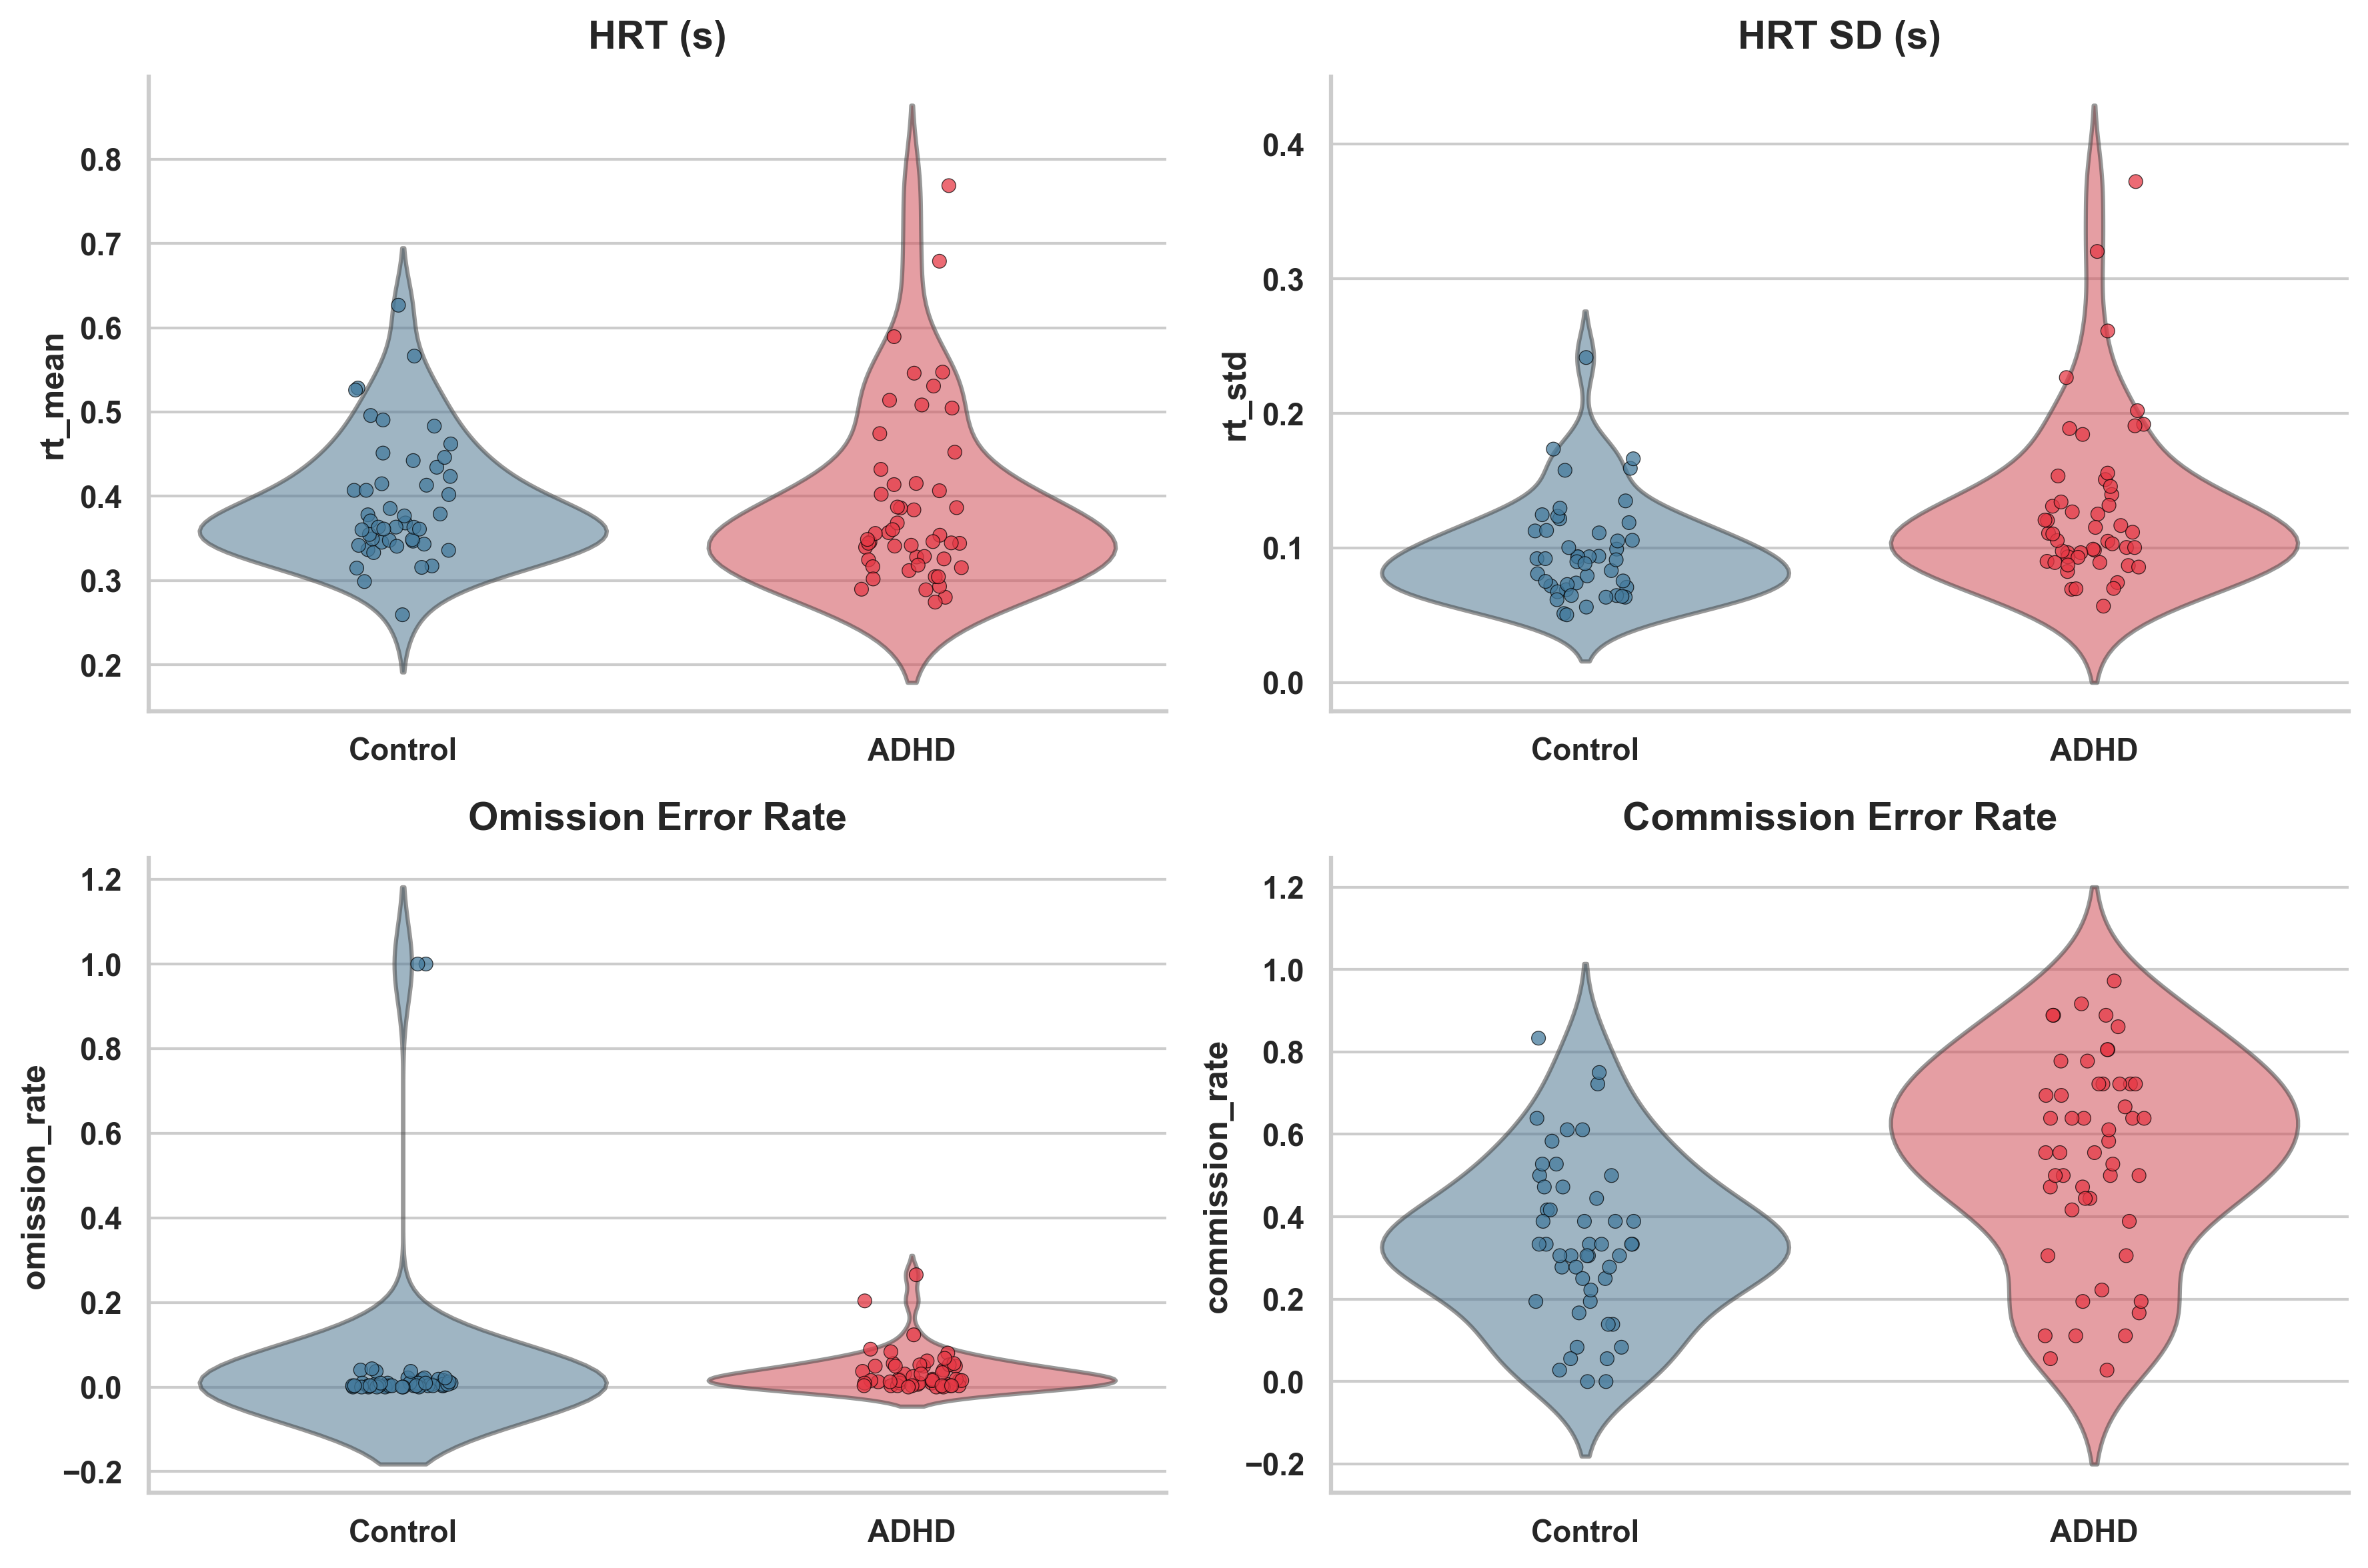

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Publication-style settings
plt.rcParams.update({
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (var, lbl) in zip(axes.flatten(), METRICS):

    pdata = subj_df[[var, "group"]].dropna()

    sns.violinplot(
        data=pdata,
        x="group",
        y=var,
        order=GROUP_ORDER,
        palette=PALETTE,
        inner=None,
        alpha=0.55,
        linewidth=1.5,
        ax=ax
    )

    sns.stripplot(
        data=pdata,
        x="group",
        y=var,
        order=GROUP_ORDER,
        palette=PALETTE,
        size=5,
        alpha=0.75,
        jitter=True,
        edgecolor="black",
        linewidth=0.3,
        ax=ax
    )

    # Bold title
    ax.set_title(lbl, fontsize=14, fontweight='bold', pad=10)

    # Bold axis labels
    ax.set_xlabel("")
    ax.set_ylabel(var, fontsize=12, fontweight='bold')

    # Bold tick labels
    ax.tick_params(axis='both', labelsize=11, width=1.5)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    # Thicker borders
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


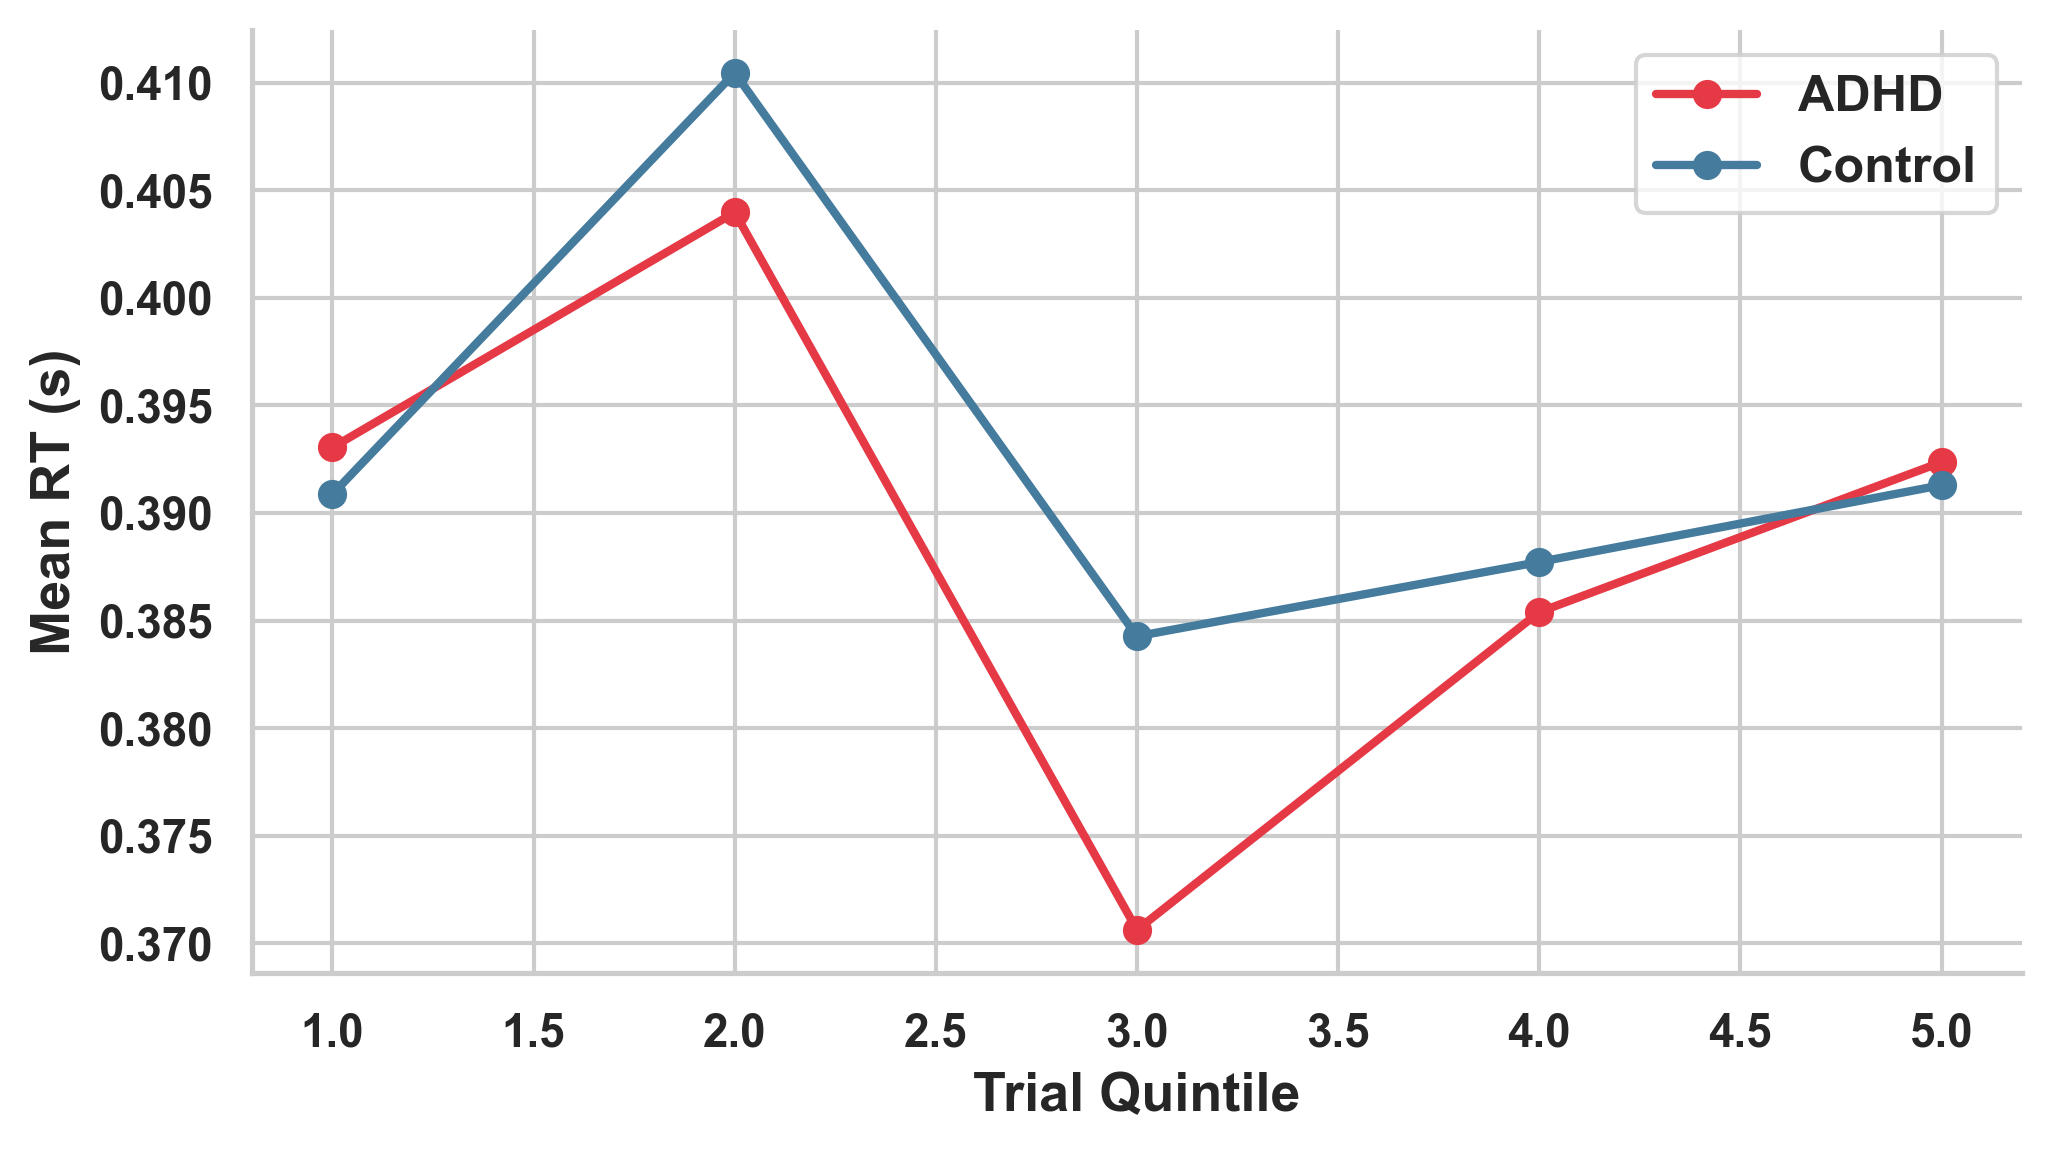

In [14]:

# BUG 
# FIX: dropna first, then pd.to_numeric after converting Categorical to string

go_df = cpt_df[(cpt_df["stimulus"]!=0) & cpt_df["rt_sec"].notna()].copy()

# Create quintiles per subject, handle duplicates gracefully
go_df["quintile"] = go_df.groupby("subject")["trial"].transform(
    lambda x: pd.qcut(x, 5, labels=[1,2,3,4,5], duplicates="drop")
)

# FIX: convert Categorical → int safely
go_df["quintile"] = pd.to_numeric(go_df["quintile"].astype(str), errors="coerce")
go_df = go_df.dropna(subset=["quintile"])
go_df["quintile"] = go_df["quintile"].astype(int)

qt = go_df.groupby(["group","quintile"])["rt_sec"].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
for grp, col in PALETTE.items():
    sub = qt[qt["group"]==grp].sort_values("quintile")
    ax.plot(sub["quintile"], sub["rt_sec"], marker="o", label=grp, color=col, lw=2)
ax.set_xlabel("Trial Quintile"); ax.set_ylabel("Mean RT (s)")
ax.legend(); plt.tight_layout(); plt.show()


## Section 3 — Mixed-Effects Modeling

In [15]:
def fit_lme(df, formula):
    """Fit linear mixed-effects model with subject random intercept."""
    mdf = df.dropna(subset=["rt_sec","ADHD","trial"]).copy()
    mdf["trial_z"] = (mdf["trial"] - mdf["trial"].mean()) / mdf["trial"].std()
    md = smf.mixedlm(formula, data=mdf, groups=mdf["subject"])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return md.fit(method="lbfgs", maxiter=500)


lme_base = fit_lme(cpt_df, "rt_sec ~ ADHD + trial_z + ADHD:trial_z")
print("=== Model 1 (base): rt ~ ADHD + trial + ADHD×trial ===")
print(lme_base.summary())


=== Model 1 (base): rt ~ ADHD + trial + ADHD×trial ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rt_sec    
No. Observations: 31986   Method:             REML      
No. Groups:       97      Scale:              0.0156    
Min. group size:  240     Log-Likelihood:     20874.6966
Max. group size:  350     Converged:          Yes       
Mean group size:  329.8                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.391    0.013 29.832 0.000  0.366  0.417
ADHD          -0.002    0.018 -0.126 0.900 -0.038  0.034
trial_z       -0.003    0.001 -3.003 0.003 -0.005 -0.001
ADHD:trial_z   0.000    0.001  0.137 0.891 -0.003  0.003
Group Var      0.008    0.009                           



## problem in this result in sex or age may be missing or null values


In [16]:
if all(c in cpt_df.columns for c in ["AGE","SEX"]):
    lme_cov = fit_lme(cpt_df, "rt_sec ~ ADHD + trial_z + ADHD:trial_z + AGE + SEX")
    print("=== Model 2 (adjusted): rt ~ ADHD + trial + ADHD×trial + AGE + SEX ===")
    print(lme_cov.summary())
else:
    print("AGE/SEX not available — skipping adjusted model.")


=== Model 2 (adjusted): rt ~ ADHD + trial + ADHD×trial + AGE + SEX ===
              Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     rt_sec
No. Observations:       31986       Method:                 REML  
No. Groups:             97          Scale:                  0.0156
Min. group size:        240         Log-Likelihood:         inf   
Max. group size:        350         Converged:              Yes   
Mean group size:        329.8                                     
------------------------------------------------------------------
             Coef.   Std.Err.    z    P>|z|    [0.025     0.975]  
------------------------------------------------------------------
Intercept     0.003 312716.402  0.000 1.000 -612912.882 612912.888
ADHD          0.003 164593.313  0.000 1.000 -322596.962 322596.968
trial_z      -0.003      0.001 -3.007 0.003      -0.005     -0.001
ADHD:trial_z  0.000      0.001  0.134 0.893      -0.003      0.003
AGE   

table should be used in paper

In [17]:

# BUG 
# when zipped with fe_params rows.
# FIX: extract conf_int rows that match fe_params index only.

fe_idx  = lme_base.fe_params.index          # fixed-effect term names
ci_full = lme_base.conf_int()               # may include extra rows (RE variance)
ci_fe   = ci_full.loc[fe_idx]               # keep only fixed-effect rows — FIX

lme_fe = pd.DataFrame({
    "Term":        fe_idx,
    "Coefficient": lme_base.fe_params.values,
    "SE":          lme_base.bse_fe.values,
    "z":           lme_base.tvalues[fe_idx].values,
    "p":           lme_base.pvalues[fe_idx].values,
    "CI low":      ci_fe.iloc[:, 0].values.round(4),
    "CI high":     ci_fe.iloc[:, 1].values.round(4),
})
lme_fe["Sig"] = lme_fe["p"].apply(
    lambda p: "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
)
print("=== Table 2: LME Fixed Effects ===")
print(lme_fe.to_string(index=False))


=== Table 2: LME Fixed Effects ===
        Term  Coefficient       SE         z             p  CI low  CI high Sig
   Intercept     0.391362 0.013119 29.831857 1.509490e-195  0.3656   0.4171 ***
        ADHD    -0.002295 0.018273 -0.125589  9.000572e-01 -0.0381   0.0335  ns
     trial_z    -0.002999 0.000999 -3.003065  2.672749e-03 -0.0050  -0.0010  **
ADHD:trial_z     0.000191 0.001398  0.136867  8.911358e-01 -0.0025   0.0029  ns


## Section 4 — Kalman Filter (Redundancy Assessment)

In [18]:
if not KALMAN_AVAILABLE:
    print("pykalman not installed — skipping Section 4.")
else:
    def fit_kalman_subject(rt_series):
        obs = rt_series[~np.isnan(rt_series)].reshape(-1, 1)
        if len(obs) < 20:
            return {"state_noise": np.nan, "obs_noise": np.nan}
        kf = KalmanFilter(
            transition_matrices=[[1]], observation_matrices=[[1]],
            transition_covariance=[[0.01]], observation_covariance=[[0.1]],
            initial_state_mean=[obs[0,0]], n_dim_state=1, n_dim_obs=1
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kf_em = kf.em(obs, n_iter=30)
        return {"state_noise": float(kf_em.transition_covariance[0,0]),
                "obs_noise":   float(kf_em.observation_covariance[0,0])}

    go_kal = cpt_df[cpt_df["stimulus"]!=0].copy()
    kal_recs = []
    for sid, grp in go_kal.groupby("subject"):
        p = fit_kalman_subject(grp.sort_values("trial")["rt_sec"].values)
        p["subject"] = sid
        kal_recs.append(p)

    kalman_df = pd.DataFrame(kal_recs).merge(
        subj_df[["subject","ADHD","group","rt_std"]], on="subject", how="left"
    )
    print(f"Kalman fitted: {kalman_df['state_noise'].notna().sum()} subjects")
    print(kalman_df.groupby("group")[["state_noise","obs_noise"]].mean().round(6))


Kalman fitted: 97 subjects
         state_noise  obs_noise
group                          
ADHD        0.001476   0.013830
Control     0.000855   0.007299


In [19]:
if KALMAN_AVAILABLE and "kalman_df" in dir():
    kal_clean = kalman_df.dropna(subset=["state_noise","obs_noise","rt_std","ADHD"])

    r_q, p_q = pearsonr(kal_clean["state_noise"], kal_clean["rt_std"])
    r_r, p_r = pearsonr(kal_clean["obs_noise"],   kal_clean["rt_std"])
    print(f"r(Q, IIV) = {r_q:.3f}, p = {p_q:.4f}")
    print(f"r(R, IIV) = {r_r:.3f}, p = {p_r:.4f}")
    print("If |r| > 0.7 → Kalman redundant with IIV\n")

    y_k = kal_clean["ADHD"].values
    cv_k = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED)
    for fname, fdata in [
        ("IIV only",  kal_clean[["rt_std"]].values),
        ("Q only",    kal_clean[["state_noise"]].values),
        ("R only",    kal_clean[["obs_noise"]].values),
        ("IIV+Q+R",   kal_clean[["rt_std","state_noise","obs_noise"]].values),
    ]:
        pipe = Pipeline([("sc", StandardScaler()),
                          ("lr", LogisticRegression(max_iter=1000, random_state=SEED))])
        auc = cross_val_score(pipe, fdata, y_k, cv=cv_k, scoring="roc_auc")
        print(f"  {fname:12s}: AUC = {auc.mean():.3f} ± {auc.std():.3f}")


r(Q, IIV) = 0.873, p = 0.0000
r(R, IIV) = 0.931, p = 0.0000
If |r| > 0.7 → Kalman redundant with IIV

  IIV only    : AUC = 0.714 ± 0.056
  Q only      : AUC = 0.709 ± 0.083
  R only      : AUC = 0.704 ± 0.053
  IIV+Q+R     : AUC = 0.720 ± 0.070


## Section 5 — Drift Diffusion Modeling (Main Analysis)
**Bug fixed:** `Sample.from_numpy_array()` no longer receives `dt`/`T_dur` (wrong API). Those args belong to `Model`.


In [20]:
def prepare_ddm_data(df):
    """Extract Go-trial RT + accuracy for DDM fitting."""
    d = df[(df["stimulus"]!=0) & df["rt_sec"].notna()].copy()
    d = d[["subject","rt_sec","correct","ADHD"]].rename(columns={"rt_sec":"rt"})
    d = d[(d["rt"] >= 0.15) & (d["rt"] <= 2.0)]
    return d

ddm_data = prepare_ddm_data(cpt_df)
print(f"DDM input: {ddm_data.shape[0]} trials, {ddm_data['subject'].nunique()} subjects")


DDM input: 30433 trials, 97 subjects


In [21]:

def fit_ddm_subject(rt_arr, correct_arr, subject_id=None):
    """
    Fit 3-param DDM (v, a, t) per subject using pyddm.
    Returns {v, a, t} or NaN on failure.
    Model spec:
      - Drift: Fittable [0.05, 5.0]
      - Noise: Fixed at 1.0 (Ratcliff identification convention)
      - Boundary: Fittable [0.3, 2.5]
      - NonDecision: Fittable [0.1, 0.7]
      - Lapse: 2% uniform mixture (prevents inf likelihood on CPT data)
    """
    if not DDM_AVAILABLE:
        return {"v": np.nan, "a": np.nan, "t": np.nan}
    try:
        # FIX: removed dt=0.001, T_dur=2.5 from Sample — wrong API location
        sample = Sample.from_numpy_array(
            np.column_stack([rt_arr, correct_arr.astype(int)])
        )
        model = Model(
            name    = f"subj_{subject_id}",
            drift   = DriftConstant(drift=Fittable(minval=0.05, maxval=5.0)),
            noise   = NoiseConstant(noise=1.0),
            bound   = BoundConstant(B=Fittable(minval=0.3, maxval=2.5)),
            overlay = OverlayChain(overlays=[
                OverlayNonDecision(nondectime=Fittable(minval=0.1, maxval=0.7)),
                OverlayUniformMixture(umixturecoef=0.02)
            ]),
            dx=0.01, dt=0.01, T_dur=2.5   # T_dur correctly on Model, not Sample
        )
        fit_adjust_model(sample, model,
                          fitting_method="differential_evolution",
                          lossfunction=LossRobustLikelihood,
                          verbose=False)
        params = model.get_model_parameters()
        return {"v": float(params[0]), "a": float(params[1]), "t": float(params[2])}
    except Exception as e:
        print(f"  Subject {subject_id} failed: {e}")
        return {"v": np.nan, "a": np.nan, "t": np.nan}


if DDM_AVAILABLE:
    ddm_records = []
    subjects = ddm_data["subject"].unique()
    for i, sid in enumerate(subjects):
        sub = ddm_data[ddm_data["subject"]==sid]
        res = fit_ddm_subject(sub["rt"].values, sub["correct"].values, sid)
        res["subject"] = sid
        ddm_records.append(res)
        if (i+1) % 10 == 0:
            print(f"  {i+1}/{len(subjects)} subjects fitted...")
    ddm_params_raw = pd.DataFrame(ddm_records)
    ok = ddm_params_raw[["v","a","t"]].notna().all(axis=1).sum()
    print(f"\nSuccessfully fitted: {ok}/{len(subjects)}")
else:
    ddm_params_raw = pd.DataFrame(columns=["subject","v","a","t"])
    print("pyddm unavailable.")


Info: Params [4.08607623 0.77905907 0.19555623] gave -311.50855333481104
Info:pyddm:Params [4.08607623 0.77905907 0.19555623] gave -311.50855333481104
Info: Params [5.         1.00413655 0.13598336] gave -334.6841050785473
Info:pyddm:Params [5.         1.00413655 0.13598336] gave -334.6841050785473
Info: Params [4.03740331 1.50971602 0.10647421] gave -163.68096316253065
Info:pyddm:Params [4.03740331 1.50971602 0.10647421] gave -163.68096316253065
Info: Params [5.         1.22485952 0.10113624] gave -303.41947886861044
Info:pyddm:Params [5.         1.22485952 0.10113624] gave -303.41947886861044
Info: Params [5.         1.07699353 0.17871528] gave -347.4879374222081
Info:pyddm:Params [5.         1.07699353 0.17871528] gave -347.4879374222081
Info: Params [4.55939365 0.91349405 0.15213847] gave -322.020701492408
Info:pyddm:Params [4.55939365 0.91349405 0.15213847] gave -322.020701492408
Info: Params [5.         1.28286438 0.15030175] gave -328.98963677681206
Info:pyddm:Params [5.        

  10/97 subjects fitted...


Info: Params [5.         1.18192119 0.18537697] gave -342.75658739002927
Info:pyddm:Params [5.         1.18192119 0.18537697] gave -342.75658739002927
Info: Params [5.         0.94110331 0.16306469] gave -378.7990175410755
Info:pyddm:Params [5.         0.94110331 0.16306469] gave -378.7990175410755
Info: Params [3.88108427 0.68464971 0.16514134] gave -318.6820360733754
Info:pyddm:Params [3.88108427 0.68464971 0.16514134] gave -318.6820360733754
Info: Params [5.         0.92277987 0.16584093] gave -363.7334828657088
Info:pyddm:Params [5.         0.92277987 0.16584093] gave -363.7334828657088
Info: Params [4.34526186 1.3218375  0.11843418] gave -199.30997016136328
Info:pyddm:Params [4.34526186 1.3218375  0.11843418] gave -199.30997016136328
Info: Params [5.         1.00128244 0.14275305] gave -352.6065283885397
Info:pyddm:Params [5.         1.00128244 0.14275305] gave -352.6065283885397
Info: Params [5.         0.81113688 0.22366716] gave -423.5132090853451
Info:pyddm:Params [5.         

  20/97 subjects fitted...


Info: Params [5.         2.44910128 0.1050926 ] gave -181.17545761494313
Info:pyddm:Params [5.         2.44910128 0.1050926 ] gave -181.17545761494313
Info: Params [5.         0.84186612 0.18406738] gave -400.738263616958
Info:pyddm:Params [5.         0.84186612 0.18406738] gave -400.738263616958
Info: Params [5.         1.00616202 0.21176663] gave -382.9187349267686
Info:pyddm:Params [5.         1.00616202 0.21176663] gave -382.9187349267686
Info: Params [5.         1.33420874 0.12132931] gave -314.795245953703
Info:pyddm:Params [5.         1.33420874 0.12132931] gave -314.795245953703
Info: Params [4.3090457  1.30438189 0.16144486] gave -231.44970384418352
Info:pyddm:Params [4.3090457  1.30438189 0.16144486] gave -231.44970384418352
Info: Params [4.4647461  1.44726531 0.1151772 ] gave -235.10703627015425
Info:pyddm:Params [4.4647461  1.44726531 0.1151772 ] gave -235.10703627015425
Info: Params [5.         0.54693825 0.2351573 ] gave -513.7242014192954
Info:pyddm:Params [5.         0.

...

  80/97 subjects fitted...


Info: Params [5.         1.08547656 0.13835636] gave -360.8510215646944
Info:pyddm:Params [5.         1.08547656 0.13835636] gave -360.8510215646944
Info: Params [4.7862684  0.95838725 0.11377348] gave -333.3320332034963
Info:pyddm:Params [4.7862684  0.95838725 0.11377348] gave -333.3320332034963
Info: Params [5.         1.01808345 0.10836582] gave -364.50754775161886
Info:pyddm:Params [5.         1.01808345 0.10836582] gave -364.50754775161886
Info: Params [5.         0.62201375 0.18611908] gave -458.1448961914792
Info:pyddm:Params [5.         0.62201375 0.18611908] gave -458.1448961914792
Info: Params [2.33018635 0.97867432 0.10521141] gave -14.673486847222385
Info:pyddm:Params [2.33018635 0.97867432 0.10521141] gave -14.673486847222385
Info: Params [5.         0.79597575 0.15664069] gave -431.40979941040484
Info:pyddm:Params [5.         0.79597575 0.15664069] gave -431.40979941040484
Info: Params [5.         0.67822628 0.13570034] gave -471.8598107139351
Info:pyddm:Params [5.       

  90/97 subjects fitted...


Info: Params [3.44882783 0.75218279 0.11110867] gave -177.6932733850815
Info:pyddm:Params [3.44882783 0.75218279 0.11110867] gave -177.6932733850815
Info: Params [5.         1.45542695 0.16148977] gave -317.5792602038972
Info:pyddm:Params [5.         1.45542695 0.16148977] gave -317.5792602038972
Info: Params [3.66772537 0.77762776 0.15182295] gave -273.1921753322946
Info:pyddm:Params [3.66772537 0.77762776 0.15182295] gave -273.1921753322946
Info: Params [5.         0.74974536 0.21633891] gave -417.032894092765
Info:pyddm:Params [5.         0.74974536 0.21633891] gave -417.032894092765
Info: Params [4.54632815 1.13431778 0.10353736] gave -264.2754625544179
Info:pyddm:Params [4.54632815 1.13431778 0.10353736] gave -264.2754625544179
Info: Params [2.38004396 1.0534448  0.10397685] gave -14.298129265712284
Info:pyddm:Params [2.38004396 1.0534448  0.10397685] gave -14.298129265712284



Successfully fitted: 97/97


In [22]:
from scipy.stats import ttest_ind

adhd_v = ddm_params[ddm_params.ADHD==1]["v"]
ctrl_v = ddm_params[ddm_params.ADHD==0]["v"]

ttest_ind(adhd_v, ctrl_v, equal_var=False)

NameError: name 'ddm_params' is not defined

In [23]:

if len(ddm_params_raw) > 0:    # FIX: was "if not ddm_params_raw.empty"
    ddm_cols  = ["subject"] + [c for c in ["v","a","t"] if c in ddm_params_raw.columns]
    meta_cols = ["subject","ADHD","group","AGE","SEX","rt_mean","rt_std","accuracy","response_rate"]
    clinical  = [c for c in ["ASRS","WURS","MADRS"] if c in subj_df.columns]

    ddm_params = ddm_params_raw[ddm_cols].merge(
        subj_df[meta_cols + clinical], on="subject", how="left"
    )
    for col in ["ASRS","WURS","MADRS"]:
        if col in ddm_params.columns:
            ddm_params[col] = pd.to_numeric(ddm_params[col], errors="coerce")

    print(f"DDM param table: {ddm_params.shape}")
    print(ddm_params.groupby("group")[["v","a","t"]].mean().round(4))
else:
    ddm_params = pd.DataFrame()
    print("WARNING: No DDM params — all fits failed.")


DDM param table: (97, 15)
              v       a       t
group                          
ADHD     4.5019  1.0722  0.1460
Control  4.7824  1.0755  0.1713


In [24]:
# DDM group comparisons (Table 3)
if len(ddm_params) > 0:
    DDM_LABELS = [("v","Drift Rate (v)"),
                  ("a","Boundary Sep. (a)"),
                  ("t","Non-decision Time (t, s)")]
    ddm_results = pd.DataFrame([compare_groups(ddm_params, var, lbl)
                                  for var, lbl in DDM_LABELS])
    print(" Table 3: DDM Parameter Group Comparisons")
    print(ddm_results.to_string(index=False))


 Table 3: DDM Parameter Group Comparisons
                Variable ADHD mean (SD) Control mean (SD)           Test    Statistic p-value              Effect size Sig
          Drift Rate (v)  4.502 (0.745)     4.782 (0.470) Mann-Whitney U  U = 905.500  0.0285 Rank-biserial r = -0.229   *
       Boundary Sep. (a)  1.072 (0.400)     1.075 (0.401) Mann-Whitney U U = 1164.000  0.9396 Rank-biserial r = -0.009  ns
Non-decision Time (t, s)  0.146 (0.043)     0.171 (0.047) Mann-Whitney U  U = 794.000  0.0060 Rank-biserial r = -0.324  **


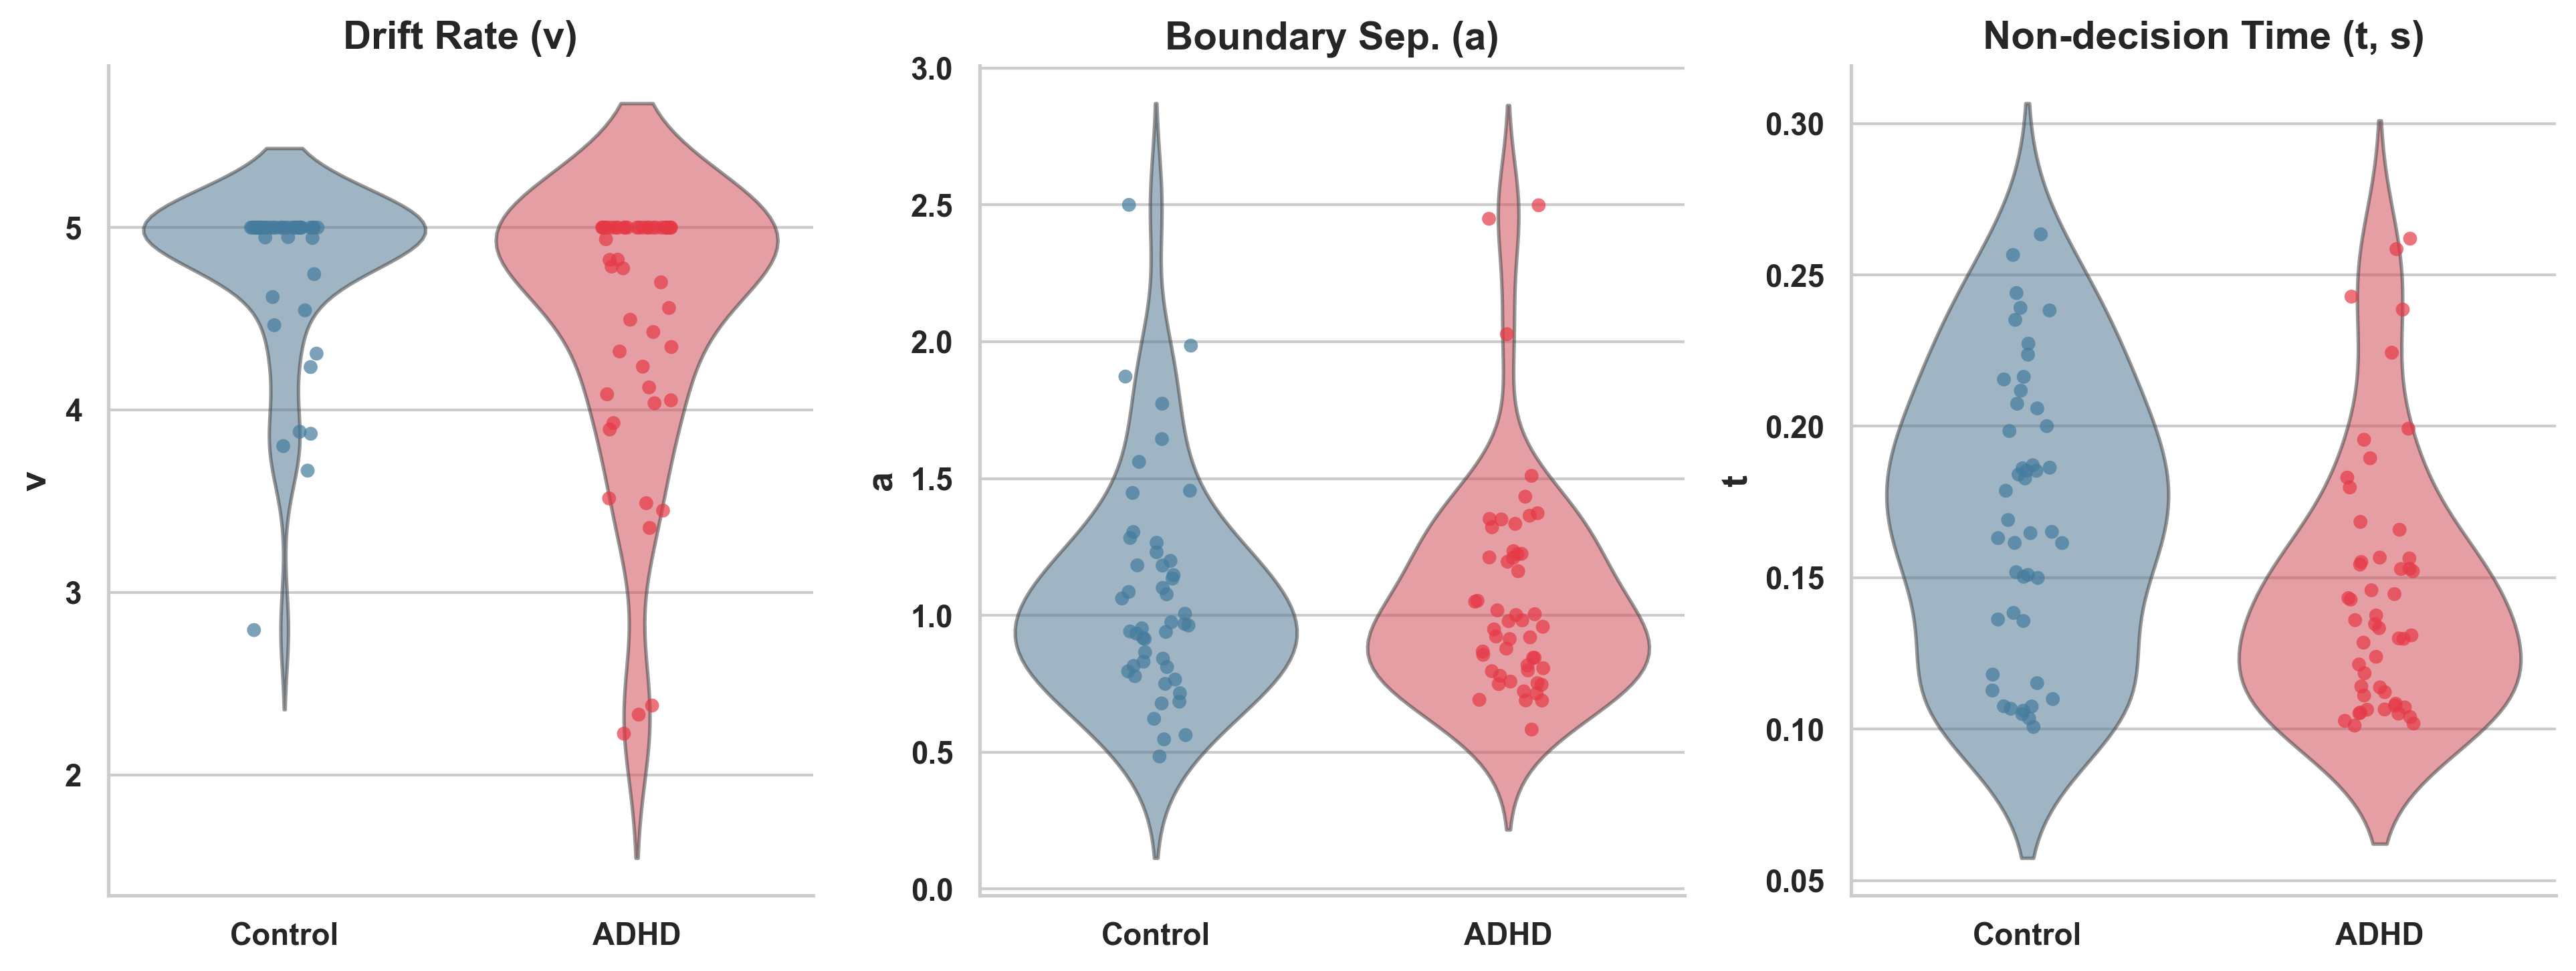

In [25]:
# DDM violin plots
if len(ddm_params) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    for ax, (var, lbl) in zip(axes, DDM_LABELS):
        pdata = ddm_params[[var,"group"]].dropna()
        sns.violinplot(data=pdata, x="group", y=var, order=GROUP_ORDER,
                       palette=PALETTE, inner=None, alpha=0.55, ax=ax)
        sns.stripplot(data=pdata, x="group", y=var, order=GROUP_ORDER,
                      palette=PALETTE, size=5, alpha=0.7, jitter=True, ax=ax)
        ax.set_title(lbl); ax.set_xlabel("")
    plt.tight_layout(); plt.show()


In [26]:
print(df.columns.tolist())

['subject', 'rt_mean', 'rt_std', 'accuracy', 'response_rate', 'omissions', 'omission_rate', 'commissions', 'commission_rate', 'hit_rate', 'false_alarm_rate', 'd_prime', 'n_trials', 'n_go', 'n_nogo', 'ADHD', 'group', 'ASRS', 'WURS', 'MADRS', 'AGE', 'SEX']


In [27]:
%whos DataFrame

Variable         Type         Data/Info
---------------------------------------
adhd             DataFrame    Shape: (50, 22)
age_tab          DataFrame    Shape: (4, 2)
ci_fe            DataFrame    Shape: (4, 2)
ci_full          DataFrame    Shape: (5, 2)
control          DataFrame    Shape: (49, 22)
cpt_df           DataFrame    Shape: (35640, 15)
ddm_data         DataFrame    Shape: (30433, 4)
ddm_params       DataFrame    Shape: (97, 15)
ddm_params_raw   DataFrame    Shape: (97, 4)
ddm_results      DataFrame    Shape: (3, 8)
df               DataFrame    Shape: (99, 22)
go_df            DataFrame    Shape: (30433, 16)
go_kal           DataFrame    Shape: (32076, 15)
grp              DataFrame    Shape: (324, 15)
kal_clean        DataFrame    Shape: (97, 6)
kalman_df        DataFrame    Shape: (99, 6)
lme_fe           DataFrame    Shape: (4, 8)
pdata            DataFrame    Shape: (97, 2)
qt               DataFrame    Shape: (10, 3)
raw_df           DataFrame    Shape: (35640, 12)


## Section 5B — Clinical Correlations (FDR-Corrected)

=== Table 4: DDM × Clinical Correlations (BH-FDR corrected) ===
DDM Param Scale  Pearson r  p (raw)  Spearman rho   p_sp  n  p (FDR) Sig (FDR)
        v  ASRS     -0.213   0.0435        -0.260 0.0133 90   0.0652        ns
        v  WURS     -0.302   0.0035        -0.278 0.0074 92   0.0158         *
        v MADRS     -0.236   0.0307        -0.217 0.0469 84   0.0652        ns
        a  ASRS     -0.214   0.0433        -0.169 0.1115 90   0.0652        ns
        a  WURS     -0.117   0.2673        -0.014 0.8922 92   0.3437        ns
        a MADRS     -0.099   0.3696        -0.027 0.8079 84   0.4158        ns
        t  ASRS     -0.247   0.0190        -0.264 0.0121 90   0.0570        ns
        t  WURS     -0.305   0.0031        -0.331 0.0013 92   0.0158         *
        t MADRS     -0.020   0.8540        -0.054 0.6227 84   0.8540        ns


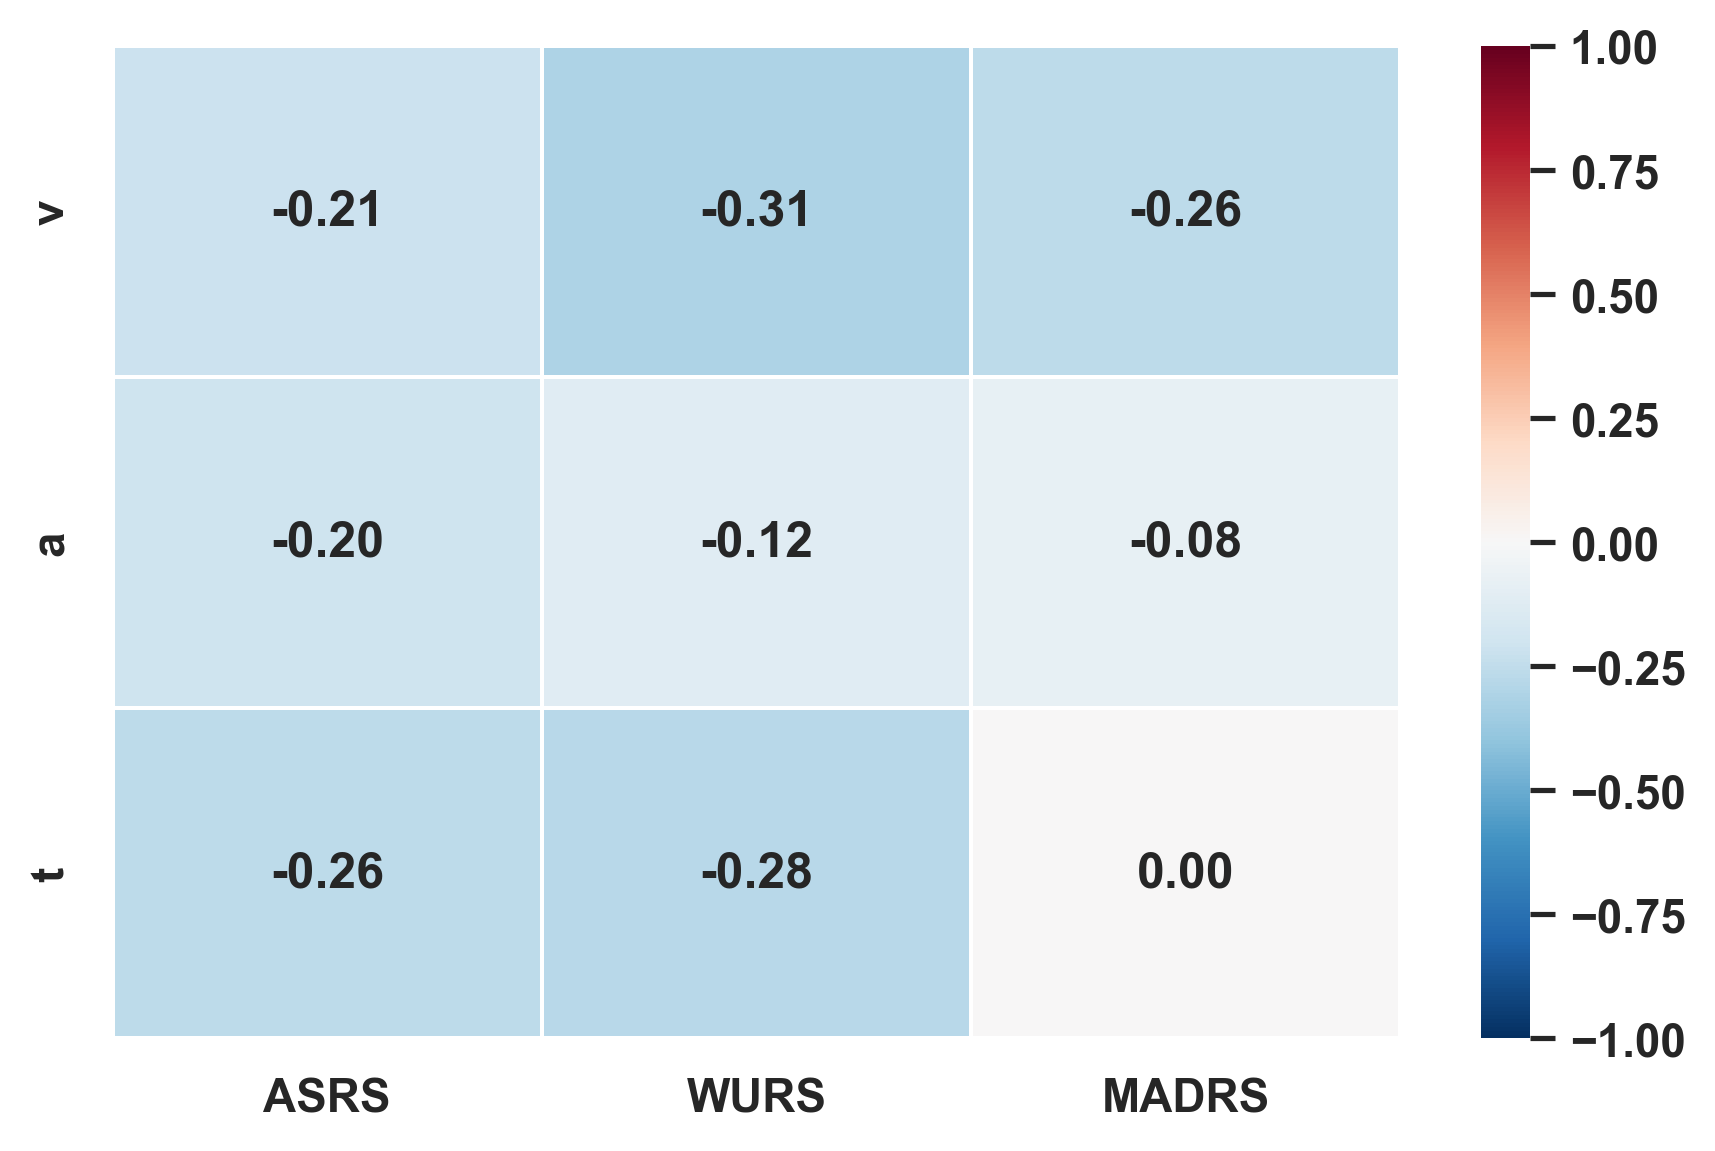

In [28]:
if len(ddm_params) > 0:
    clinical_scales = [s for s in ["ASRS","WURS","MADRS"] if s in ddm_params.columns]
    ddm_vars        = [p for p in ["v","a","t"] if p in ddm_params.columns]

    corr_rows = []
    for dvar in ddm_vars:
        for scale in clinical_scales:
            valid = ddm_params[[dvar, scale]].dropna()
            if len(valid) < 10:
                continue
            r_p, p_p = pearsonr(valid[dvar], valid[scale])
            r_s, p_s = spearmanr(valid[dvar], valid[scale])
            corr_rows.append({
                "DDM Param": dvar, "Scale": scale,
                "Pearson r": round(r_p,3), "p (raw)": round(p_p,4),
                "Spearman rho": round(r_s,3), "p_sp": round(p_s,4),
                "n": len(valid)
            })

    corr_df = pd.DataFrame(corr_rows)

    # FDR correction
    _, p_fdr, _, _ = multipletests(corr_df["p (raw)"].values, method=FDR_METHOD)
    corr_df["p (FDR)"]   = p_fdr.round(4)
    corr_df["Sig (FDR)"] = ["***" if p<0.001 else "**" if p<0.01
                              else "*" if p<0.05 else "ns" for p in p_fdr]

    print("=== Table 4: DDM × Clinical Correlations (BH-FDR corrected) ===")
    print(corr_df.to_string(index=False))

    # Heatmap
    cm_data = ddm_params[ddm_vars + clinical_scales].dropna()
    if len(cm_data) > 5:
        fig, ax = plt.subplots(figsize=(6,4))
        cm = cm_data.corr().loc[ddm_vars, clinical_scales]
        sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r",
                    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
        plt.tight_layout(); plt.show()


In [29]:
# Multivariate OLS: clinical outcome ~ DDM params + AGE + SEX 
if len(ddm_params) > 0:
    req_cols = ["v","a","t","ASRS","WURS","MADRS","AGE","SEX"]
    avail    = [c for c in req_cols if c in ddm_params.columns]
    clean    = ddm_params.dropna(subset=avail)
    print(f"Complete cases for OLS regression: n = {len(clean)}")

    for outcome in [c for c in ["ASRS","WURS","MADRS"] if c in clean.columns]:
        X_reg = sm.add_constant(clean[["v","a","t","AGE","SEX"]])
        fit   = sm.OLS(clean[outcome], X_reg).fit()
        print(f"\n=== OLS: {outcome} ~ v + a + t + AGE + SEX ===")
        print(f"  R² = {fit.rsquared:.3f}, Adj.R² = {fit.rsquared_adj:.3f}, F-p = {fit.f_pvalue:.4f}")
        coef_tbl = pd.DataFrame({
            "Term": fit.params.index,
            "Coef": fit.params.values.round(4),
            "SE":   fit.bse.values.round(4),
            "t":    fit.tvalues.values.round(3),
            "p":    fit.pvalues.values.round(4),
        })
        print(coef_tbl.to_string(index=False))


Complete cases for OLS regression: n = 78

=== OLS: ASRS ~ v + a + t + AGE + SEX ===
  R² = 0.210, Adj.R² = 0.155, F-p = 0.0039
 Term      Coef      SE      t      p
const   89.8830 13.5557  6.631 0.0000
    v   -3.3439  2.4937 -1.341 0.1842
    a  -12.1432  3.9970 -3.038 0.0033
    t -114.7110 36.6536 -3.130 0.0025
  AGE   -1.1834  1.4893 -0.795 0.4295
  SEX    0.8598  3.0348  0.283 0.7778

=== OLS: WURS ~ v + a + t + AGE + SEX ===
  R² = 0.206, Adj.R² = 0.151, F-p = 0.0047
 Term      Coef      SE      t      p
const  125.5336 20.9000  6.006 0.0000
    v   -9.0860  3.8448 -2.363 0.0208
    a  -13.4348  6.1625 -2.180 0.0325
    t -151.1273 56.5120 -2.674 0.0093
  AGE   -1.2019  2.2962 -0.523 0.6023
  SEX   -1.9116  4.6790 -0.409 0.6841

=== OLS: MADRS ~ v + a + t + AGE + SEX ===
  R² = 0.106, Adj.R² = 0.044, F-p = 0.1425
 Term    Coef      SE      t      p
const 27.3993  8.1197  3.374 0.0012
    v -3.1962  1.4937 -2.140 0.0358
    a -1.9282  2.3941 -0.805 0.4232
    t -0.0285 21.9551 -

In [30]:
# FIX: Logistic regression odds-ratio table — safe conf_int indexing 
# BUG in v4: logit_model.conf_int()[0] and [1] use integer column names
# which works but is fragile. FIX: use .iloc[:,0] and .iloc[:,1] explicitly.

if len(ddm_params) > 0:
    avail2 = [c for c in ["v","a","t","ADHD","AGE","SEX"] if c in ddm_params.columns]
    clean2 = ddm_params.dropna(subset=avail2)
    X_log  = sm.add_constant(clean2[["v","a","t","AGE","SEX"]])
    logit  = sm.Logit(clean2["ADHD"], X_log).fit(method="bfgs", maxiter=500, disp=False)
    print("=== Table 5: Logistic Regression — ADHD ~ v + a + t + AGE + SEX ===")
    print(logit.summary2())

    # FIX: use .iloc[:,0] and .iloc[:,1] for conf_int columns (not integer key)
    ci = logit.conf_int()
    or_df = pd.DataFrame({
        "Term":      logit.params.index,
        "OR":        np.exp(logit.params).round(3),
        "CI_lo":     np.exp(ci.iloc[:, 0]).round(3),   # FIX
        "CI_hi":     np.exp(ci.iloc[:, 1]).round(3),   # FIX
        "p":         logit.pvalues.round(4)
    })
    print("\nOdds Ratios:")
    print(or_df.to_string(index=False))


=== Table 5: Logistic Regression — ADHD ~ v + a + t + AGE + SEX ===
                        Results: Logit
Model:              Logit            Pseudo R-squared: 0.094   
Dependent Variable: ADHD             AIC:              133.7178
Date:               2026-07-08 17:52 BIC:              149.1661
No. Observations:   97               Log-Likelihood:   -60.859 
Df Model:           5                LL-Null:          -67.189 
Df Residuals:       91               LLR p-value:      0.026783
Converged:          1.0000           Scale:            1.0000  
Method:             MLE                                        
----------------------------------------------------------------
           Coef.    Std.Err.     z     P>|z|    [0.025    0.975]
----------------------------------------------------------------
const       5.9839    2.4788   2.4141  0.0158    1.1256  10.8422
v          -0.6271    0.4412  -1.4213  0.1552   -1.4919   0.2377
a          -0.8395    0.6237  -1.3460  0.1783   -2.0620 

## Section 6 — Classification Benchmarking (Upgraded)
**Bugs fixed:**
- Bootstrap CI loop now uses simple train/test split instead of nested 3-fold CV on bootstrap samples (avoids class-imbalance crash with small n)
- Permutation test uses `n_jobs=1` (was `-1` causing memory issues and slow parallelism overhead)


In [31]:
BEHAVIORAL_FEATURES = [
    "rt_mean",
    "rt_std",
    "accuracy",
    "omission_rate",
    "commission_rate",
    "d_prime"
]
DDM_FEATURES        = [c for c in ["v","a","t"] if c in ddm_params.columns] if len(ddm_params) > 0 else []
COMBINED_FEATURES   = BEHAVIORAL_FEATURES + DDM_FEATURES

if len(ddm_params) == 0 or not DDM_FEATURES:
    print("WARNING: DDM params unavailable — skipping benchmark.")
    bench_df = pd.DataFrame()
else:
    bench_df = subj_df.merge(
        ddm_params[["subject"] + DDM_FEATURES], on="subject", how="inner"
    ).dropna(subset=COMBINED_FEATURES + ["ADHD"])

    X_beh  = bench_df[BEHAVIORAL_FEATURES].values
    X_ddm  = bench_df[DDM_FEATURES].values
    X_comb = bench_df[COMBINED_FEATURES].values
    y      = bench_df["ADHD"].values
    print(f"Benchmark: n={len(bench_df)}, ADHD={y.sum()}, Control={(y==0).sum()}")


Benchmark: n=97, ADHD=50, Control=47


In [32]:

# BUG used StratifiedKFold(3) inside bootstrap loop → crashes when
# bootstrapped sample has <3 samples per class (common with n~99 + replacement)


def evaluate_feature_set_full(X, y, label, n_permute=N_PERMUTE):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    clfs = {
        "Logistic Reg.": LogisticRegression(max_iter=1000, random_state=SEED),
        "SVM (RBF)":     SVC(kernel="rbf", probability=True, random_state=SEED),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
    }
    rows = []
    for clf_name, clf in clfs.items():
        pipe = Pipeline([("sc", StandardScaler()), ("clf", clf)])

        # Standard CV
        cv_res   = cross_validate(pipe, X, y, cv=cv,
                                   scoring=["roc_auc","accuracy","f1"],
                                   return_train_score=False)
        auc_mean = np.mean(cv_res["test_roc_auc"])
        auc_std  = np.std(cv_res["test_roc_auc"])

        # FIX: Bootstrap CI — simple 80/20 split on bootstrap sample
        rng = np.random.default_rng(SEED)
        boot_aucs = []
        for _ in range(500):
            idx = rng.choice(len(y), size=len(y), replace=True)
            Xb, yb = X[idx], y[idx]
            if len(np.unique(yb)) < 2:
                continue
            n_tr = int(0.8 * len(yb))
            try:
                pipe.fit(Xb[:n_tr], yb[:n_tr])
                prob = pipe.predict_proba(Xb[n_tr:])[:,1]
                if len(np.unique(yb[n_tr:])) == 2:
                    from sklearn.metrics import roc_auc_score as ras
                    boot_aucs.append(ras(yb[n_tr:], prob))
            except Exception:
                continue
        ci_lo, ci_hi = (np.percentile(boot_aucs, [2.5, 97.5])
                         if len(boot_aucs) > 10 else (np.nan, np.nan))

        # FIX: n_jobs=1 (was -1 — slow overhead + memory issues with small n)
        _, _, perm_p = permutation_test_score(
            pipe, X, y, cv=cv, scoring="roc_auc",
            n_permutations=n_permute, random_state=SEED, n_jobs=1
        )

        rows.append({
            "Features":   label,
            "Classifier": clf_name,
            "AUC":        f"{auc_mean:.3f} ± {auc_std:.3f}",
            "95% CI":     f"[{ci_lo:.3f}, {ci_hi:.3f}]",
            "Accuracy":   f"{np.mean(cv_res['test_accuracy']):.3f}",
            "F1":         f"{np.mean(cv_res['test_f1']):.3f}",
            "Perm p":     f"{perm_p:.3f}",
            "Sig":        "***" if perm_p<0.001 else "**" if perm_p<0.01
                           else "*" if perm_p<0.05 else "ns",
            "_auc_mean":  auc_mean,
        })
    return rows


if len(bench_df) > 0:
    print("Running benchmarks (permutation n=200, n_jobs=1)...")
    all_rows = []
    for feat_label, X_feat in [("Behavioral",X_beh),("DDM",X_ddm),("Combined",X_comb)]:
        print(f"  {feat_label}...")
        all_rows.extend(evaluate_feature_set_full(X_feat, y, feat_label))

    bench_table = pd.DataFrame(all_rows)
    print("\n=== Table 6: Classification Benchmark ===")
    disp_cols = ["Features","Classifier","AUC","95% CI","Accuracy","F1","Perm p","Sig"]
    print(bench_table[disp_cols].to_string(index=False))


Running benchmarks (permutation n=200, n_jobs=1)...
  Behavioral...
  DDM...
  Combined...

=== Table 6: Classification Benchmark ===
  Features    Classifier           AUC         95% CI Accuracy    F1 Perm p Sig
Behavioral Logistic Reg. 0.749 ± 0.052 [0.557, 0.980]    0.731 0.731  0.005  **
Behavioral     SVM (RBF) 0.784 ± 0.088 [0.576, 0.990]    0.740 0.726  0.005  **
Behavioral Random Forest 0.774 ± 0.060 [0.754, 1.000]    0.721 0.712  0.005  **
       DDM Logistic Reg. 0.672 ± 0.111 [0.414, 0.911]    0.692 0.712  0.010  **
       DDM     SVM (RBF) 0.676 ± 0.097 [0.495, 0.951]    0.649 0.666  0.025   *
       DDM Random Forest 0.626 ± 0.098 [0.689, 1.000]    0.618 0.634  0.070  ns
  Combined Logistic Reg. 0.749 ± 0.061 [0.542, 0.979]    0.709 0.703  0.005  **
  Combined     SVM (RBF) 0.771 ± 0.060 [0.590, 1.000]    0.731 0.744  0.005  **
  Combined Random Forest 0.786 ± 0.065 [0.752, 1.000]    0.701 0.685  0.005  **


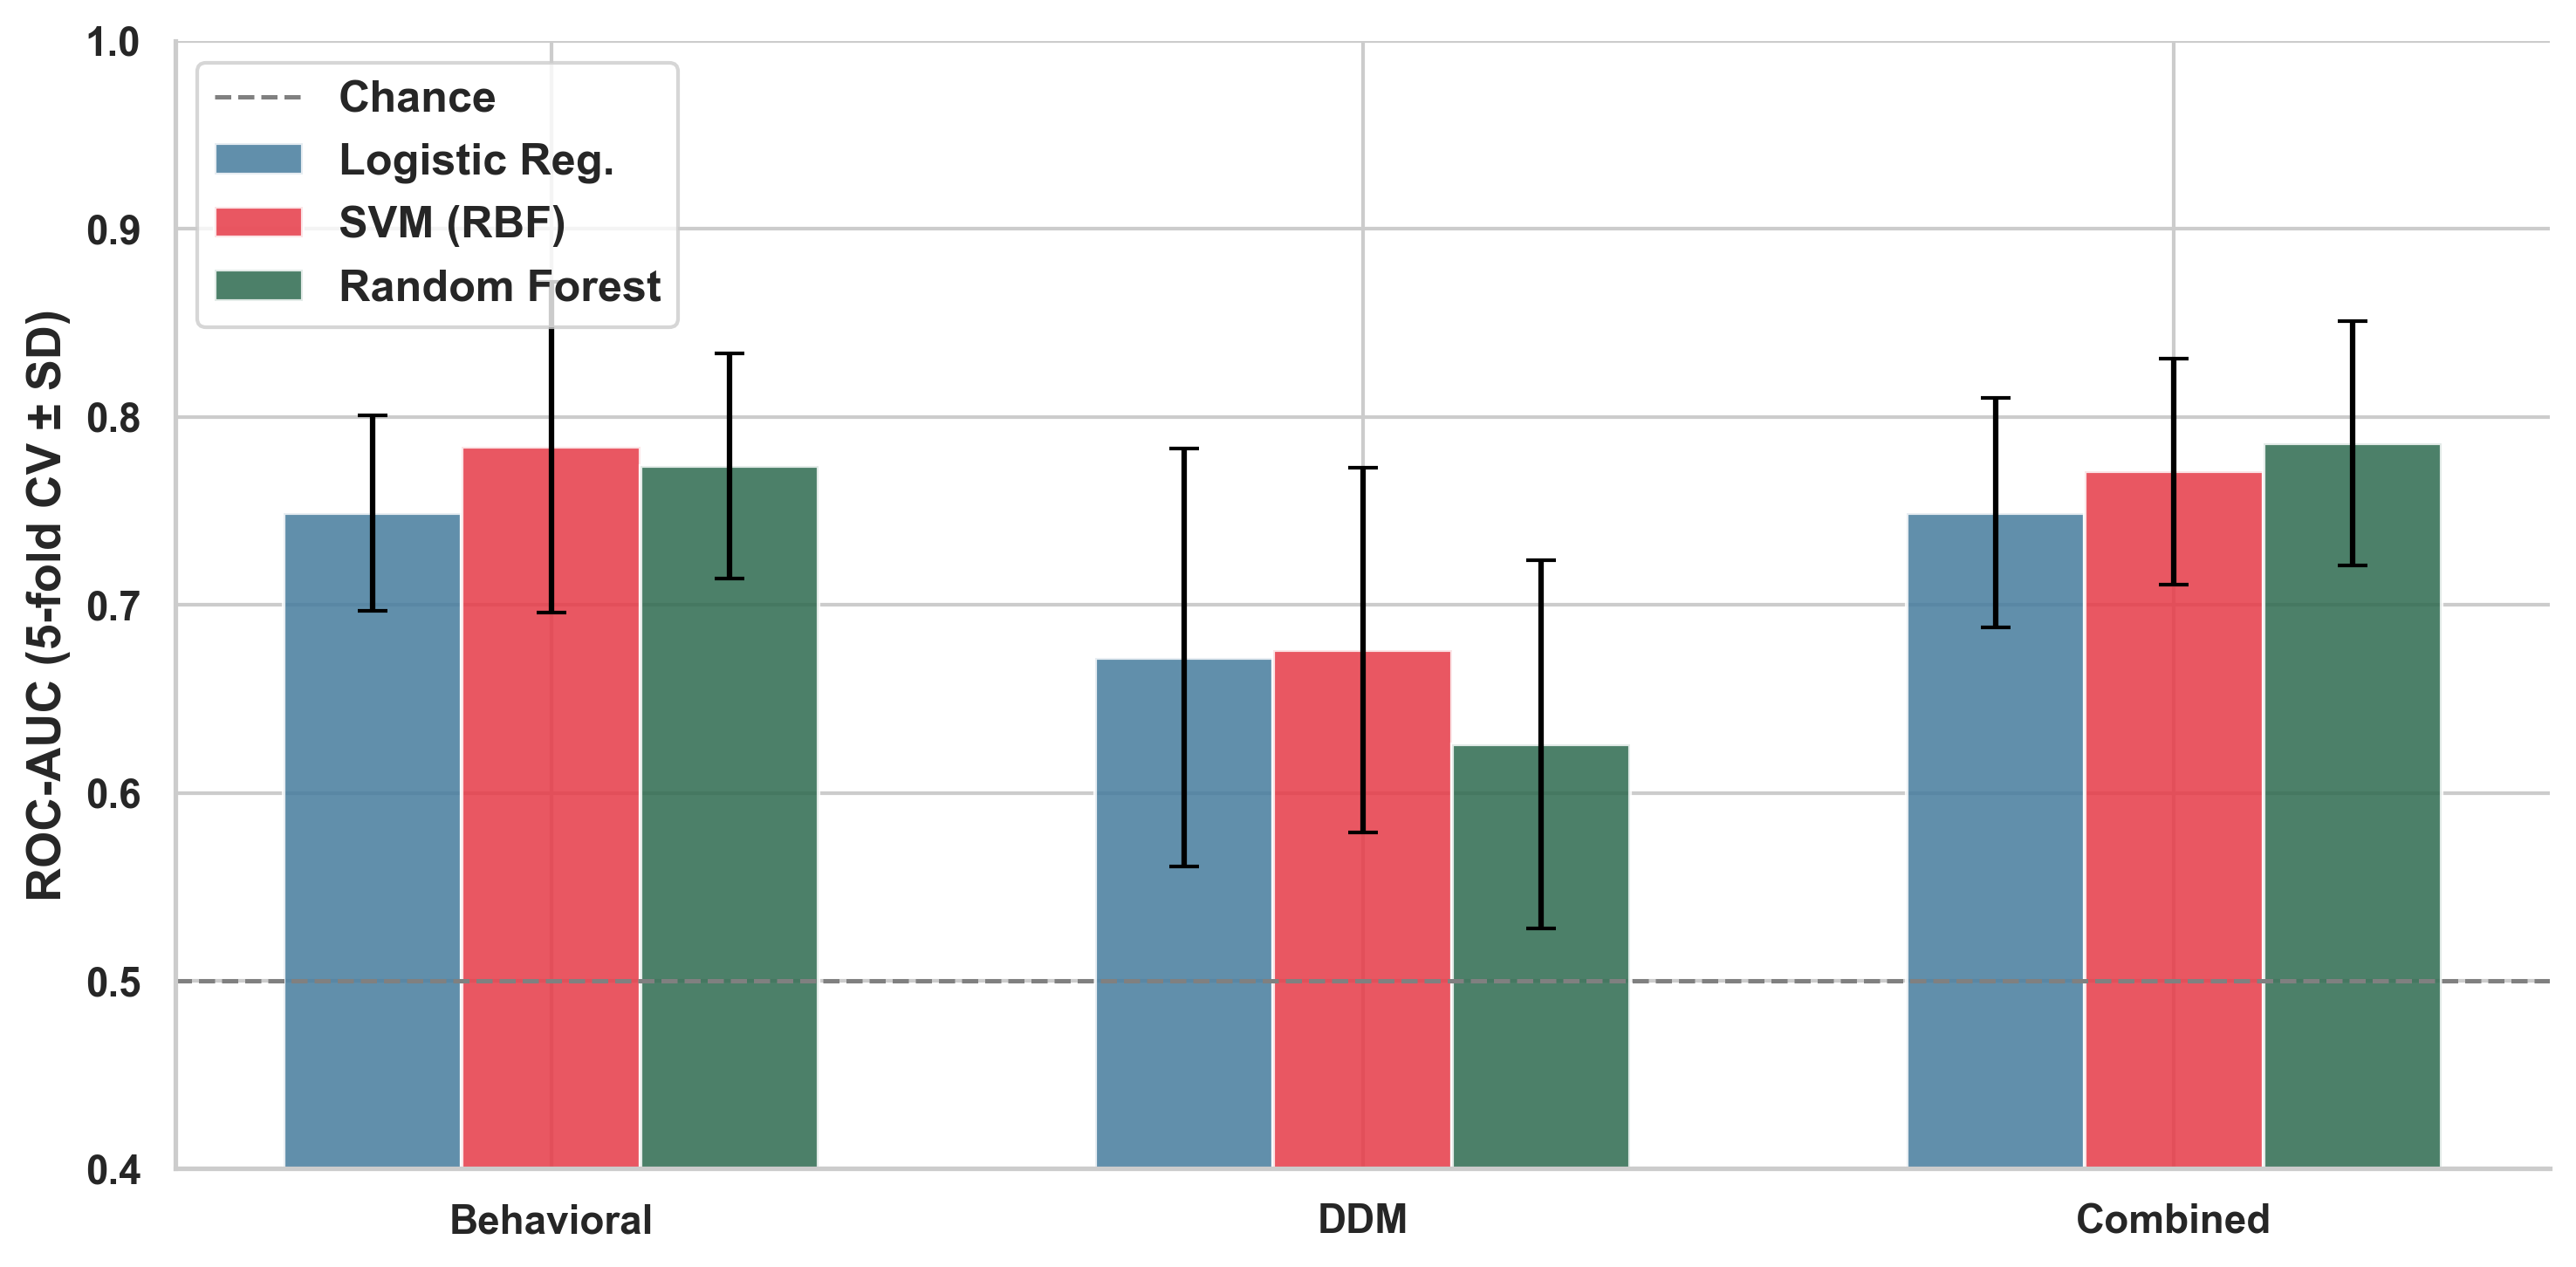

In [33]:
# AUC bar chart
if "bench_table" in dir() and len(bench_table) > 0:
    bt = bench_table.copy()
    bt["auc_m"] = bt["AUC"].apply(lambda s: float(s.split(" ±")[0]))
    bt["auc_s"] = bt["AUC"].apply(lambda s: float(s.split("± ")[1]))

    feat_sets = ["Behavioral","DDM","Combined"]
    x = np.arange(3); w = 0.22
    colors = ["#457B9D","#E63946","#2D6A4F"]

    fig, ax = plt.subplots(figsize=(10,5))
    for i, (clf, col) in enumerate(zip(bt["Classifier"].unique(), colors)):
        sub = bt[bt["Classifier"]==clf]
        means = [sub[sub["Features"]==fs]["auc_m"].values[0] for fs in feat_sets]
        ses   = [sub[sub["Features"]==fs]["auc_s"].values[0] for fs in feat_sets]
        ax.bar(x+i*w, means, w, label=clf, color=col, alpha=0.85, edgecolor="white")
        ax.errorbar(x+i*w, means, yerr=ses, fmt="none", color="black", capsize=4, lw=1.5)

    ax.set_xticks(x+w); ax.set_xticklabels(feat_sets)
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color="gray", ls="--", lw=1.2, label="Chance")
    ax.set_ylabel("ROC-AUC (5-fold CV ± SD)")
    ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()


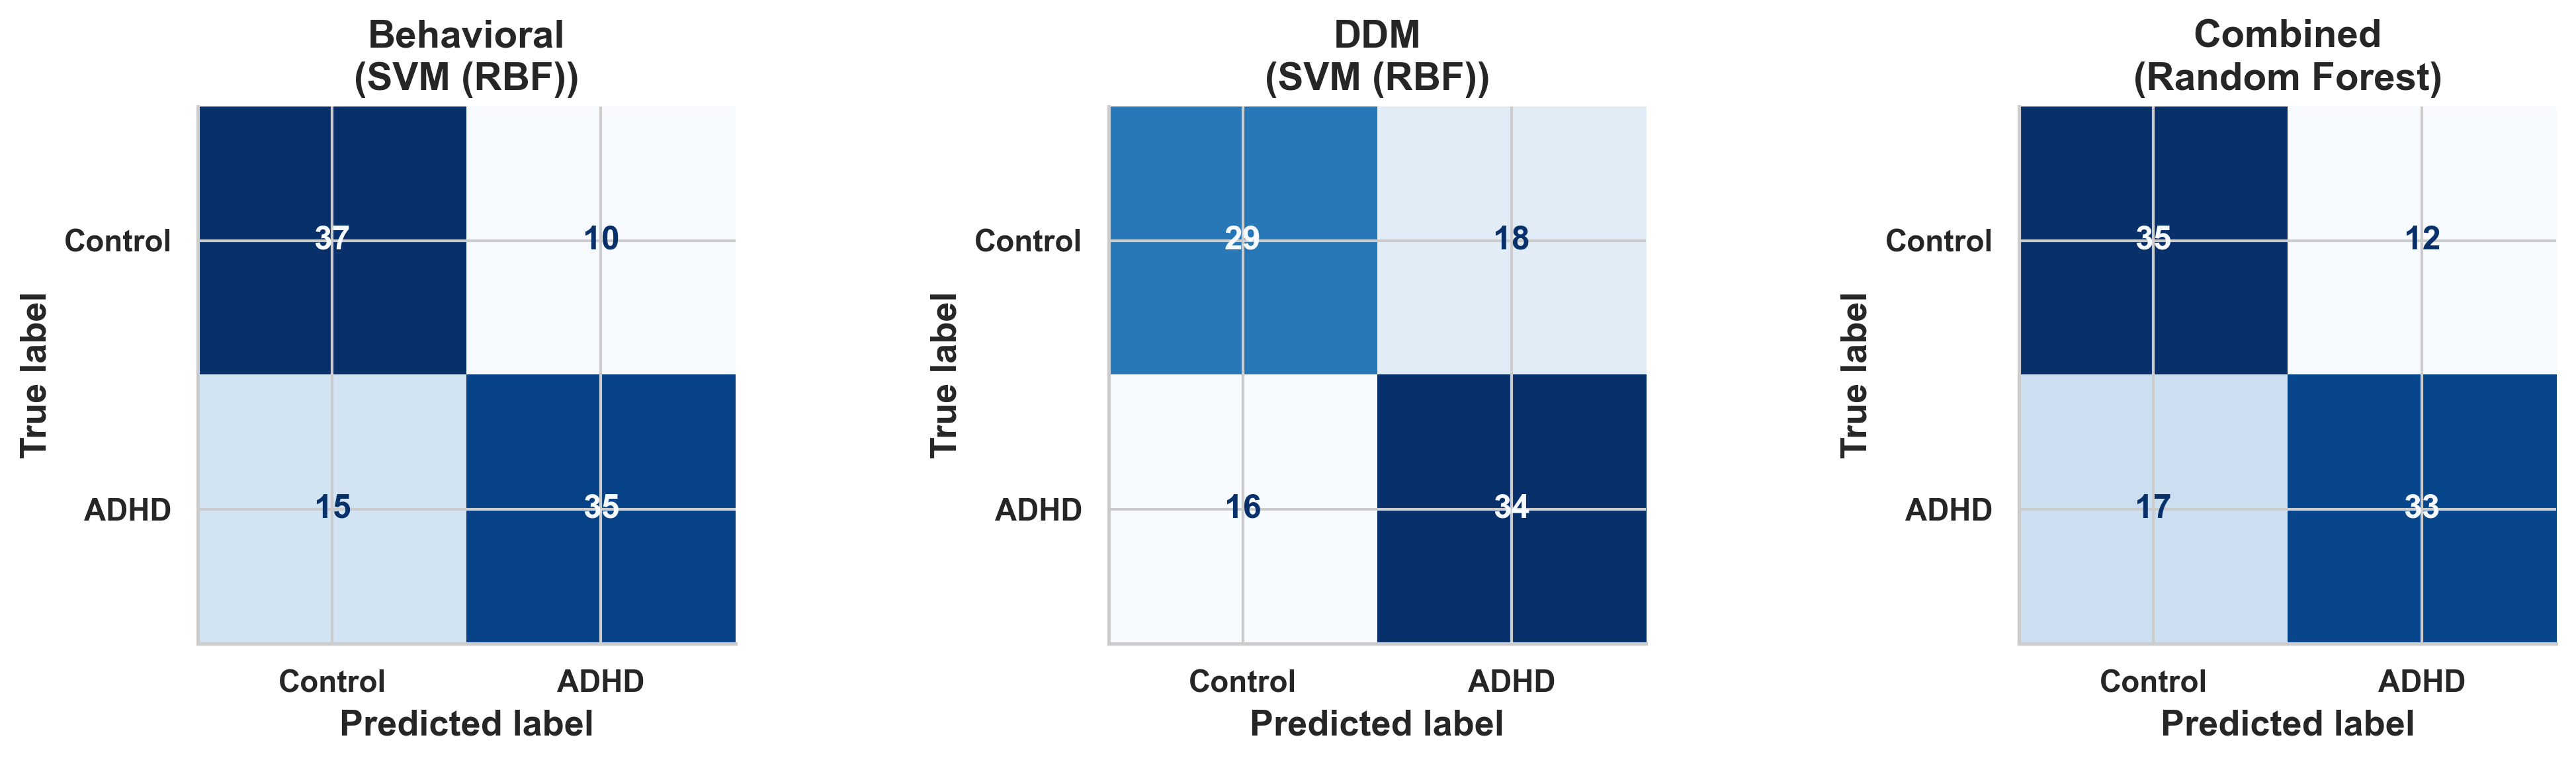

In [34]:
# Confusion matrices
if "bench_table" in dir() and len(bench_table) > 0:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    clf_map = {
        "Logistic Reg.": LogisticRegression(max_iter=1000, random_state=SEED),
        "SVM (RBF)":     SVC(kernel="rbf", probability=True, random_state=SEED),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
    }
    for ax, (flabel, Xf) in zip(axes, [("Behavioral",X_beh),("DDM",X_ddm),("Combined",X_comb)]):
        best = (bench_table[bench_table["Features"]==flabel]
                .sort_values("_auc_mean", ascending=False)
                .iloc[0]["Classifier"])
        pipe = Pipeline([("sc", StandardScaler()), ("clf", clf_map[best])])
        y_pred = np.zeros(len(y), dtype=int)
        for tr, te in cv.split(Xf, y):
            pipe.fit(Xf[tr], y[tr])
            y_pred[te] = pipe.predict(Xf[te])
        cm = confusion_matrix(y, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=["Control","ADHD"]).plot(
            ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{flabel}\n({best})", fontweight="bold")
    plt.tight_layout(); plt.show()


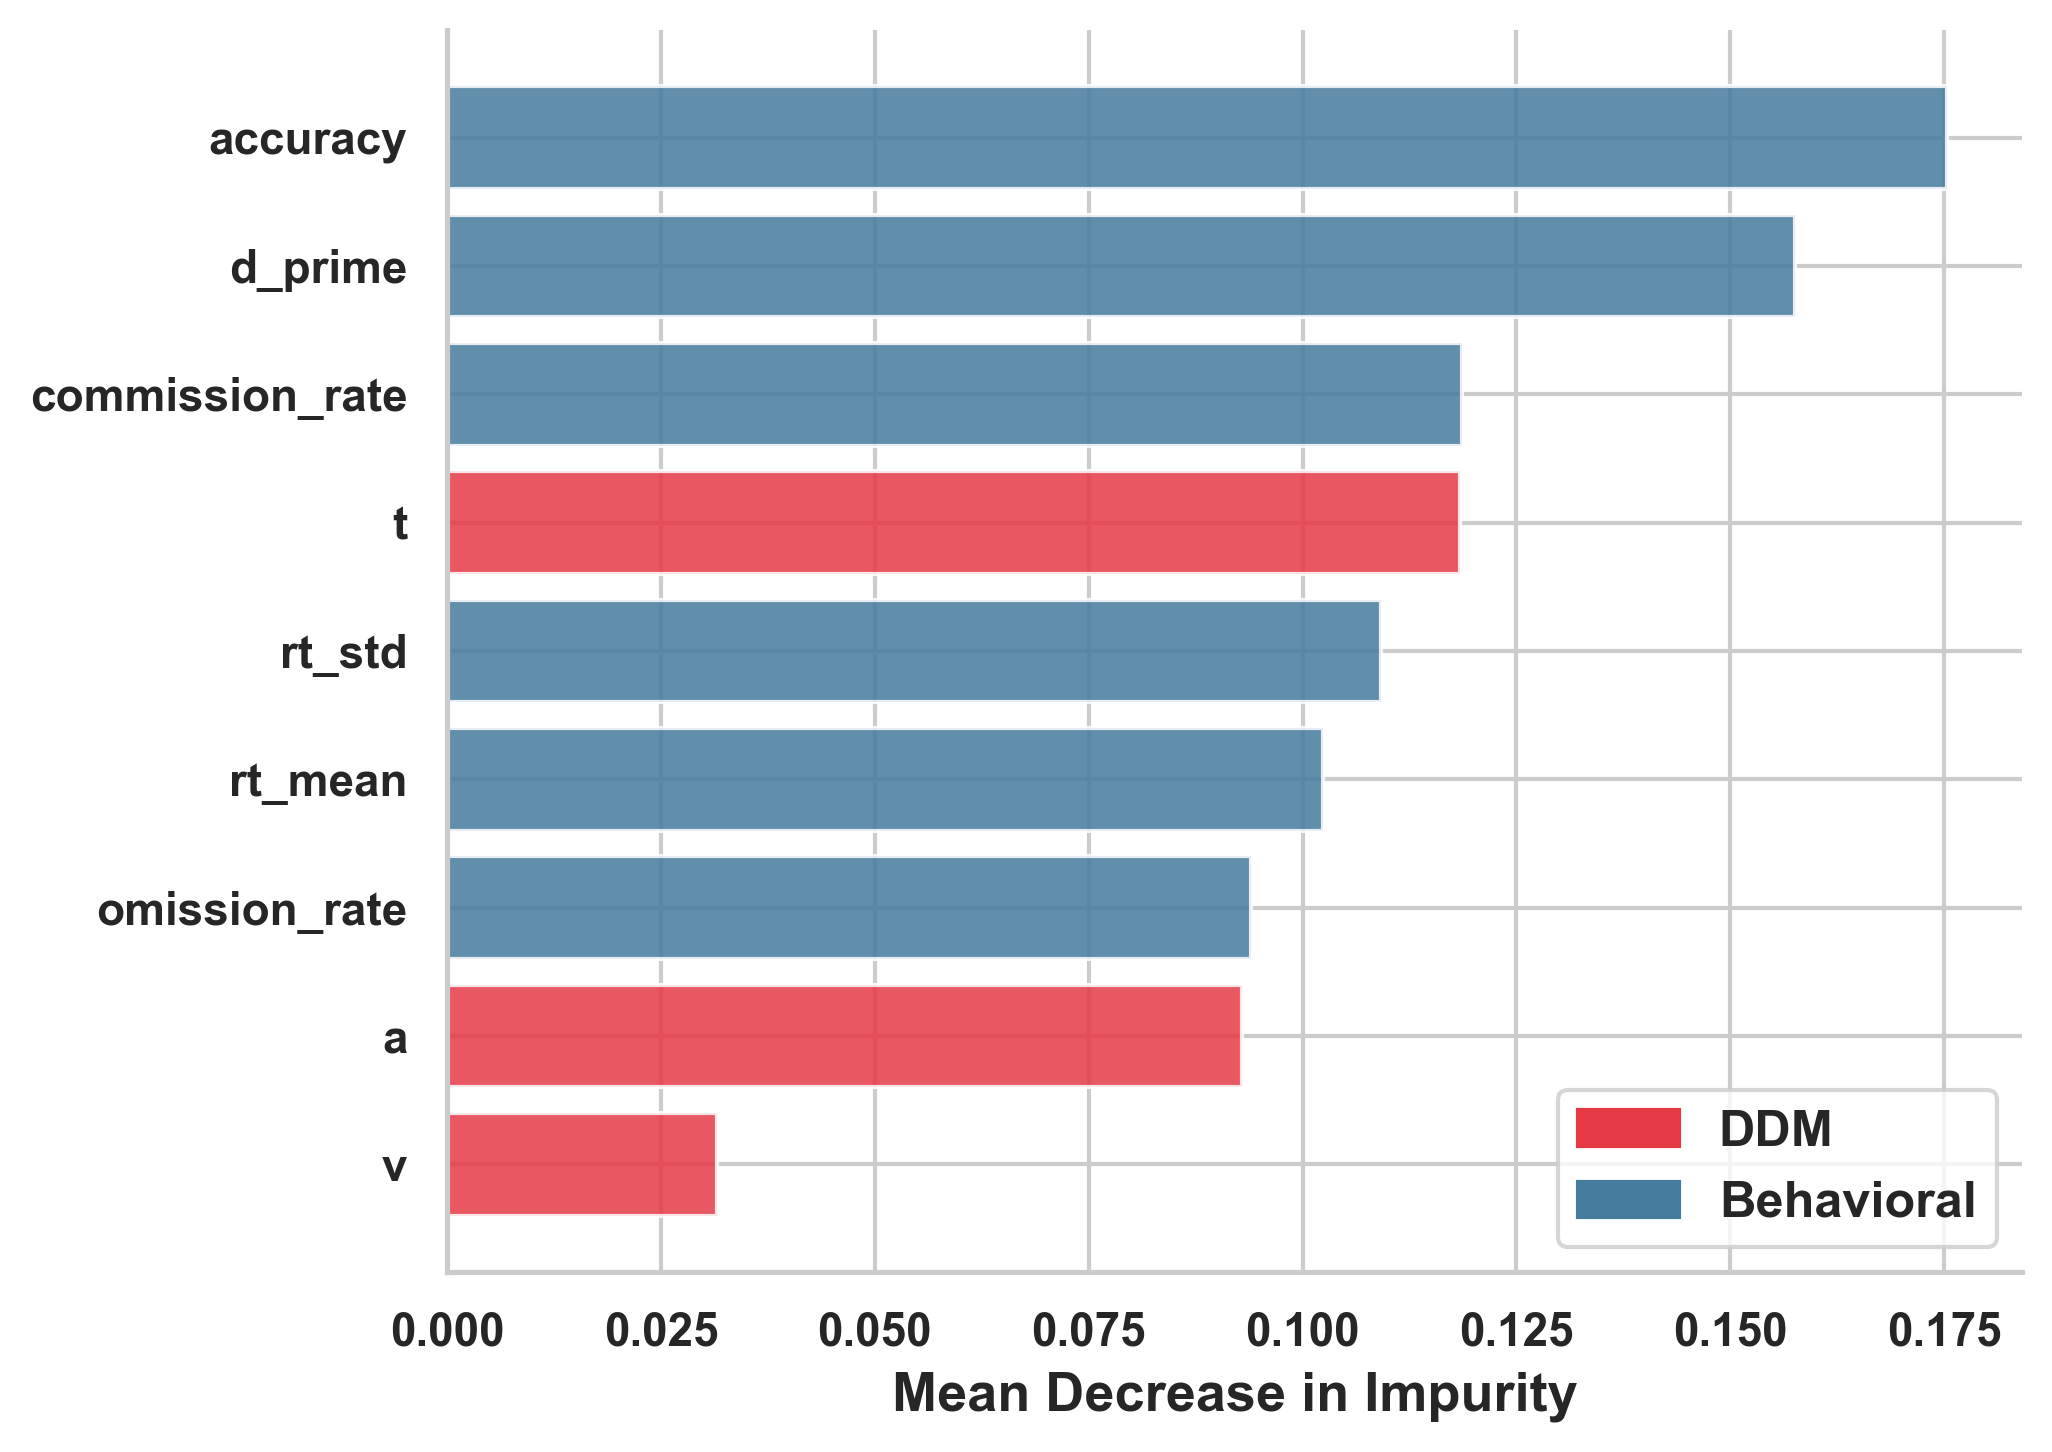

        Feature  Importance
       accuracy    0.175343
        d_prime    0.157546
commission_rate    0.118664
              t    0.118455
         rt_std    0.109213
        rt_mean    0.102390
  omission_rate    0.093980
              a    0.092862
              v    0.031548


In [35]:
# Feature importance
if "bench_df" in dir() and len(bench_df) > 0 and DDM_FEATURES:
    rf = Pipeline([("sc", StandardScaler()),
                    ("clf", RandomForestClassifier(n_estimators=500, random_state=SEED))])
    rf.fit(X_comb, y)
    imp = rf.named_steps["clf"].feature_importances_

    imp_df = (pd.DataFrame({"Feature": COMBINED_FEATURES, "Importance": imp})
              .sort_values("Importance"))
    colors_imp = ["#E63946" if f in DDM_FEATURES else "#457B9D" for f in imp_df["Feature"]]

    fig, ax = plt.subplots(figsize=(7,5))
    ax.barh(imp_df["Feature"], imp_df["Importance"], color=colors_imp, alpha=0.85, edgecolor="white")
    ax.legend(handles=[Patch(color="#E63946",label="DDM"), Patch(color="#457B9D",label="Behavioral")])
    ax.set_xlabel("Mean Decrease in Impurity")
    plt.tight_layout(); plt.show()

    print(imp_df.sort_values("Importance", ascending=False).to_string(index=False))


In [38]:
# ============================================================
# EXHAUSTIVE FEATURE-COMBINATION SEARCH
# Best existing model: SVM-RBF
# ============================================================

import itertools
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. ALL FEATURES TO TEST
# ------------------------------------------------------------
ALL_FEATURES = [f for f in COMBINED_FEATURES if f in subj_df.columns]

# Keep only columns that actually exist
ALL_FEATURES = [
    f for f in ALL_FEATURES
    if f in subj_df.columns
]

print("Features available:")
print(ALL_FEATURES)

print(
    f"\nTotal possible combinations: "
    f"{2**len(ALL_FEATURES) - 1}"
)

# ------------------------------------------------------------
# 2. TARGET
# ------------------------------------------------------------

y = subj_df["ADHD"].astype(int).values

# ------------------------------------------------------------
# 3. SAME SVM-RBF MODEL FOR EVERY COMBINATION
# ------------------------------------------------------------

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=42
        )
    )
])

# Same CV splits for every combination
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 4. TEST EVERY FEATURE COMBINATION
# ------------------------------------------------------------

results = []

for n_features in range(1, len(ALL_FEATURES) + 1):

    for combo in itertools.combinations(
        ALL_FEATURES,
        n_features
    ):

        X = subj_df[list(combo)].copy()

        # Out-of-fold class predictions
        y_pred = cross_val_predict(
            model,
            X,
            y,
            cv=cv,
            method="predict",
            n_jobs=-1
        )

        # Out-of-fold probabilities
        y_prob = cross_val_predict(
            model,
            X,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y,
            y_pred,
            labels=[0, 1]
        ).ravel()

        # ADHD correct classification
        sensitivity = tp / (tp + fn)

        # Control correct classification
        specificity = tn / (tn + fp)

        results.append({

            "Features":
                " + ".join(combo),

            "N Features":
                len(combo),

            "ADHD Correct (%)":
                100 * sensitivity,

            "Control Correct (%)":
                100 * specificity,

            "Overall Accuracy (%)":
                100 * accuracy_score(
                    y,
                    y_pred
                ),

            "Balanced Accuracy (%)":
                100 * balanced_accuracy_score(
                    y,
                    y_pred
                ),

            "ROC-AUC":
                roc_auc_score(
                    y,
                    y_prob
                ),

            "F1":
                f1_score(
                    y,
                    y_pred
                )
        })


# ------------------------------------------------------------
# 5. CREATE RANKED TABLE
# ------------------------------------------------------------

combo_results = pd.DataFrame(results)

combo_results = (
    combo_results
    .sort_values(
        [
            "Balanced Accuracy (%)",
            "ROC-AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

combo_results.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(combo_results) + 1
    )
)

# ------------------------------------------------------------
# 6. DISPLAY TOP 20
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TOP 20 FEATURE COMBINATIONS — SVM-RBF")
print("=" * 100)

print(
    combo_results.head(20)
    .round({
        "ADHD Correct (%)": 1,
        "Control Correct (%)": 1,
        "Overall Accuracy (%)": 1,
        "Balanced Accuracy (%)": 1,
        "ROC-AUC": 3,
        "F1": 3
    })
    .to_string(index=False)
)


# ------------------------------------------------------------
# 7. BEST COMBINATION
# ------------------------------------------------------------

best = combo_results.iloc[0]

print("\n" + "=" * 100)
print("BEST FEATURE COMBINATION")
print("=" * 100)

print(f"Features: {best['Features']}")
print(f"Number of features: {best['N Features']}")
print(
    f"ADHD correctly classified: "
    f"{best['ADHD Correct (%)']:.1f}%"
)
print(
    f"Controls correctly classified: "
    f"{best['Control Correct (%)']:.1f}%"
)
print(
    f"Overall accuracy: "
    f"{best['Overall Accuracy (%)']:.1f}%"
)
print(
    f"Balanced accuracy: "
    f"{best['Balanced Accuracy (%)']:.1f}%"
)
print(
    f"ROC-AUC: "
    f"{best['ROC-AUC']:.3f}"
)
print(
    f"F1-score: "
    f"{best['F1']:.3f}"
)


# ------------------------------------------------------------
# 8. SAVE FULL AND TOP-20 RESULTS
# ------------------------------------------------------------

combo_results.to_csv(
    "All_Feature_Combinations_SVM.csv",
    index=False
)

combo_results.head(20).to_csv(
    "Top20_Feature_Combinations_SVM.csv",
    index=False
)

combo_results.head(20).to_excel(
    "Top20_Feature_Combinations_SVM.xlsx",
    index=False
)

print("\nSaved successfully.")

Features available:
['rt_mean', 'rt_std', 'accuracy', 'omission_rate', 'commission_rate', 'd_prime']

Total possible combinations: 63

TOP 20 FEATURE COMBINATIONS — SVM-RBF
 Rank                                                                Features  N Features  ADHD Correct (%)  Control Correct (%)  Overall Accuracy (%)  Balanced Accuracy (%)  ROC-AUC    F1
    1                                               commission_rate + d_prime           2              70.0                 79.6                  74.7                   74.8    0.768 0.737
    2                                              accuracy + commission_rate           2              68.0                 79.6                  73.7                   73.8    0.768 0.723
    3                                         omission_rate + commission_rate           2              70.0                 77.6                  73.7                   73.8    0.769 0.729
    4                                                       rt_std + ac

## Section 7 — Composite Publication Figure

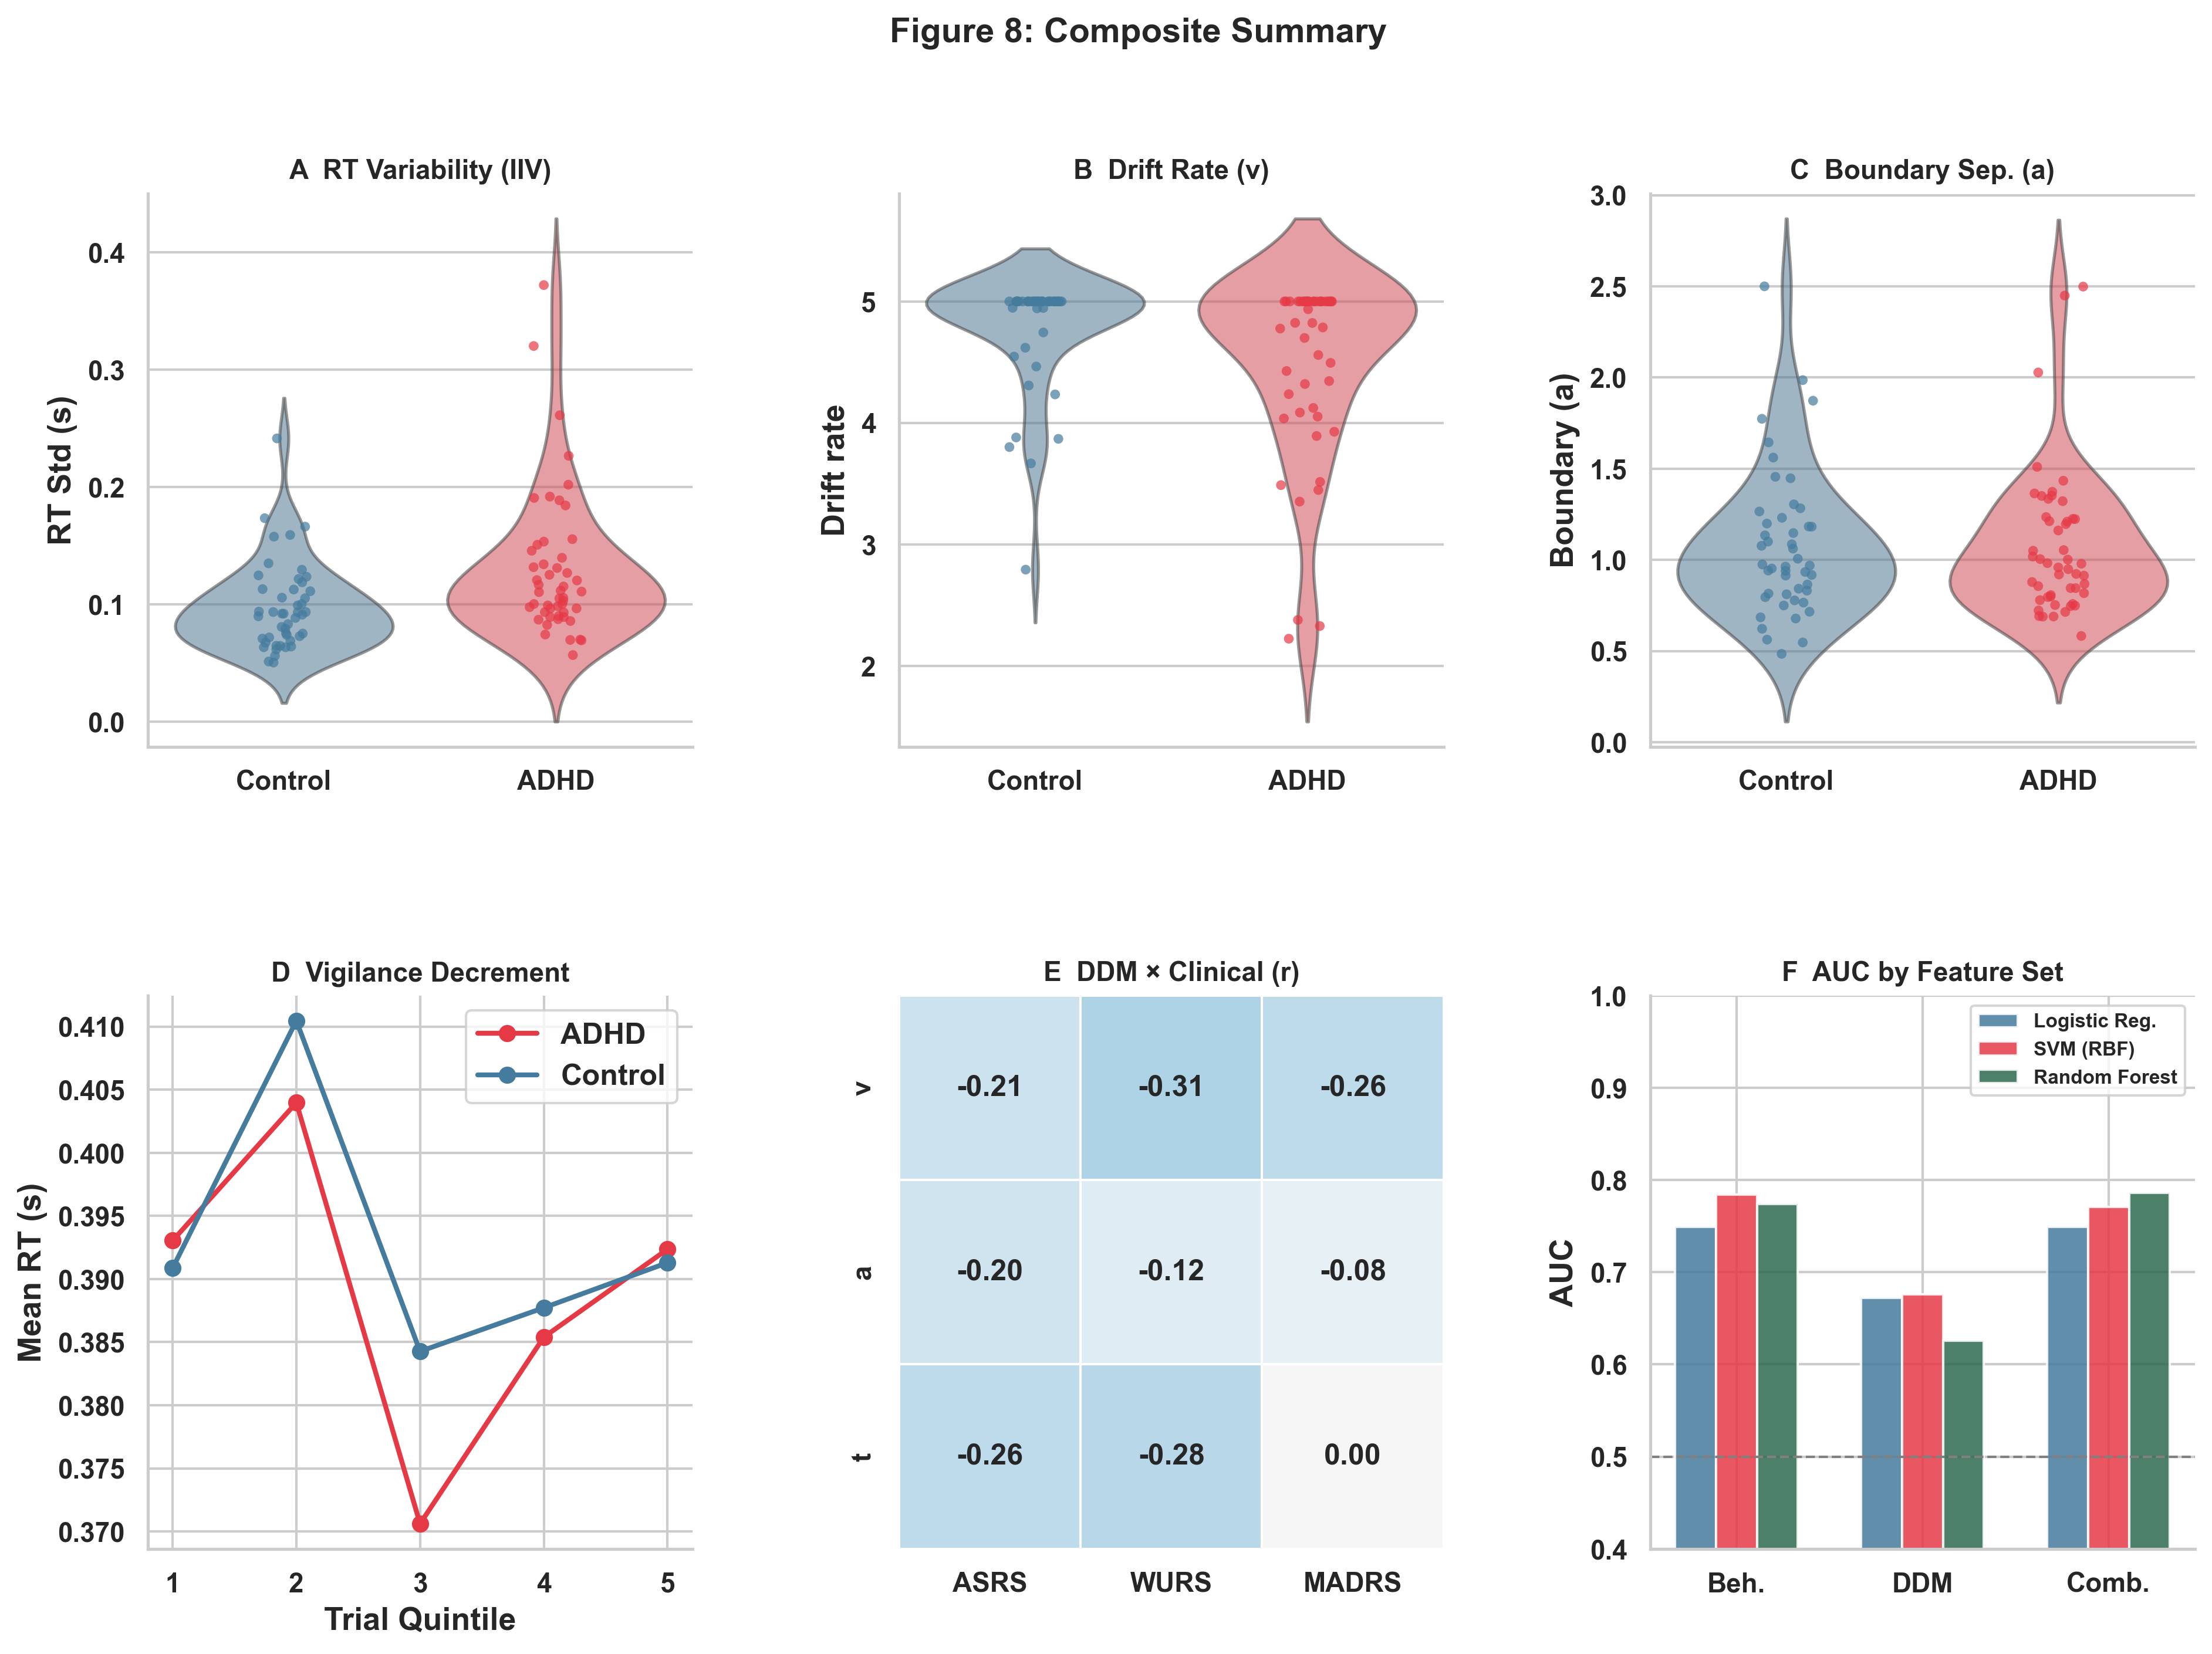

In [ ]:
if len(ddm_params) > 0 and "bench_table" in dir() and len(bench_table) > 0:
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    def vplot(ax, df, var, title, ylabel=""):
        pdata = df[[var,"group"]].dropna()
        sns.violinplot(data=pdata, x="group", y=var, order=GROUP_ORDER,
                       palette=PALETTE, inner=None, alpha=0.55, ax=ax)
        sns.stripplot(data=pdata, x="group", y=var, order=GROUP_ORDER,
                      palette=PALETTE, size=4, alpha=0.7, jitter=True, ax=ax)
        ax.set_title(title, fontweight="bold", fontsize=11); ax.set_xlabel("")
        if ylabel: ax.set_ylabel(ylabel)

    vplot(fig.add_subplot(gs[0,0]), subj_df,   "rt_std", "A  RT Variability (IIV)", "RT Std (s)")
    vplot(fig.add_subplot(gs[0,1]), ddm_params, "v",     "B  Drift Rate (v)", "Drift rate")
    vplot(fig.add_subplot(gs[0,2]), ddm_params, "a",     "C  Boundary Sep. (a)", "Boundary (a)")

    # Panel D: vigilance decrement (reuse fixed quintile logic)
    ax_d = fig.add_subplot(gs[1,0])
    go2 = cpt_df[(cpt_df["stimulus"]!=0) & cpt_df["rt_sec"].notna()].copy()
    go2["quintile"] = go2.groupby("subject")["trial"].transform(
        lambda x: pd.qcut(x, 5, labels=[1,2,3,4,5], duplicates="drop"))
    go2["quintile"] = pd.to_numeric(go2["quintile"].astype(str), errors="coerce")
    go2 = go2.dropna(subset=["quintile"])
    go2["quintile"] = go2["quintile"].astype(int)
    qt2 = go2.groupby(["group","quintile"])["rt_sec"].mean().reset_index()
    for grp, col in PALETTE.items():
        sub = qt2[qt2["group"]==grp].sort_values("quintile")
        ax_d.plot(sub["quintile"], sub["rt_sec"], marker="o", color=col, label=grp, lw=2)
    ax_d.set_xlabel("Trial Quintile"); ax_d.set_ylabel("Mean RT (s)")
    ax_d.set_title("D  Vigilance Decrement", fontweight="bold", fontsize=11); ax_d.legend()

    # Panel E: correlation heatmap
    ax_e = fig.add_subplot(gs[1,1])
    cl_e  = [s for s in ["ASRS","WURS","MADRS"] if s in ddm_params.columns]
    dv_e  = [p for p in ["v","a","t"] if p in ddm_params.columns]
    if cl_e:
        cm_e = ddm_params[dv_e + cl_e].dropna().corr().loc[dv_e, cl_e]
        sns.heatmap(cm_e, annot=True, fmt=".2f", cmap="RdBu_r",
                    center=0, vmin=-1, vmax=1, ax=ax_e, linewidths=0.5, cbar=False)
    ax_e.set_title("E  DDM × Clinical (r)", fontweight="bold", fontsize=11)

    # Panel F: AUC bar chart
    ax_f = fig.add_subplot(gs[1,2])
    bt2 = bench_table.copy()
    bt2["auc_m"] = bt2["AUC"].apply(lambda s: float(s.split(" ±")[0]))
    fsets, clrs = ["Behavioral","DDM","Combined"], ["#457B9D","#E63946","#2D6A4F"]
    for i, (clf, c) in enumerate(zip(bt2["Classifier"].unique(), clrs)):
        sub = bt2[bt2["Classifier"]==clf]
        ms  = [sub[sub["Features"]==fs]["auc_m"].values[0] for fs in fsets]
        ax_f.bar(np.arange(3)+i*0.22, ms, 0.22, color=c, alpha=0.85, label=clf, edgecolor="white")
    ax_f.set_xticks(np.arange(3)+0.22); ax_f.set_xticklabels(["Beh.","DDM","Comb."])
    ax_f.axhline(0.5, color="gray", ls="--", lw=1); ax_f.set_ylim(0.4, 1.0)
    ax_f.set_ylabel("AUC"); ax_f.set_title("F  AUC by Feature Set", fontweight="bold", fontsize=11)
    ax_f.legend(fontsize=8)

    plt.suptitle("Figure 8: Composite Summary", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.savefig("fig_composite.png", dpi=200, bbox_inches="tight"); plt.show()


## Section 8 — Clean Summary Tables (Publication-Ready)

In [ ]:
if "results_table" in dir():
    print("=== TABLE 1: Behavioral Group Comparison ===")
    print(results_table.to_string(index=False))


=== TABLE 1: Behavioral Group Comparison ===
        Variable ADHD mean (SD) Control mean (SD)      U p-value Cohen's d      95% CI [d] Sig
     RT Mean (s)  0.390 (0.103)     0.393 (0.073)  996.0  0.1976    -0.030 [-0.457, 0.338]  ns
RT Std / IIV (s)  0.130 (0.061)     0.098 (0.037) 1622.0  0.0013     0.622  [0.284, 0.959]  **
        Accuracy  0.912 (0.053)     0.921 (0.171)  583.0  0.0000    -0.067 [-1.215, 0.257] ***
   Response Rate  0.922 (0.048)     0.890 (0.184) 1324.5  0.4881     0.236 [-0.323, 0.459]  ns


In [ ]:
if "ddm_results" in dir():
    print("=== TABLE 3: DDM Parameter Group Comparison ===")
    print(ddm_results.to_string(index=False))


=== TABLE 3: DDM Parameter Group Comparison ===
                Variable ADHD mean (SD) Control mean (SD)      U p-value Cohen's d       95% CI [d] Sig
          Drift Rate (v)  4.502 (0.737)     4.782 (0.465)  905.5  0.0285    -0.447 [-0.795, -0.078]   *
       Boundary Sep. (a)  1.072 (0.396)     1.075 (0.397) 1164.0  0.9396    -0.008  [-0.438, 0.386]  ns
Non-decision Time (t, s)  0.146 (0.042)     0.171 (0.046)  794.0  0.0060    -0.565 [-1.029, -0.122]  **


In [ ]:
if "corr_df" in dir():
    print("=== TABLE 4: DDM × Clinical (FDR-BH corrected) ===")
    out_cols = ["DDM Param","Scale","Pearson r","p (raw)","p (FDR)","Sig (FDR)","n"]
    print(corr_df[[c for c in out_cols if c in corr_df.columns]].to_string(index=False))


=== TABLE 4: DDM × Clinical (FDR-BH corrected) ===
DDM Param Scale  Pearson r  p (raw)  p (FDR) Sig (FDR)  n
        v  ASRS     -0.213   0.0435   0.0652        ns 90
        v  WURS     -0.302   0.0035   0.0158         * 92
        v MADRS     -0.236   0.0307   0.0652        ns 84
        a  ASRS     -0.214   0.0433   0.0652        ns 90
        a  WURS     -0.117   0.2673   0.3437        ns 92
        a MADRS     -0.099   0.3696   0.4158        ns 84
        t  ASRS     -0.247   0.0190   0.0570        ns 90
        t  WURS     -0.305   0.0031   0.0158         * 92
        t MADRS     -0.020   0.8540   0.8540        ns 84


In [ ]:
if "bench_table" in dir() and len(bench_table) > 0:
    print("=== TABLE 6: Classification Benchmark ===")
    print(bench_table[["Features","Classifier","AUC","95% CI","F1","Perm p","Sig"]].to_string(index=False))


=== TABLE 6: Classification Benchmark ===
  Features    Classifier           AUC         95% CI    F1 Perm p Sig
Behavioral Logistic Reg. 0.754 ± 0.054 [0.566, 0.980] 0.700  0.005  **
Behavioral     SVM (RBF) 0.796 ± 0.068 [0.589, 0.990] 0.764  0.005  **
Behavioral Random Forest 0.755 ± 0.092 [0.737, 1.000] 0.681  0.005  **
       DDM Logistic Reg. 0.672 ± 0.111 [0.414, 0.911] 0.712  0.010  **
       DDM     SVM (RBF) 0.676 ± 0.097 [0.495, 0.951] 0.666  0.025   *
       DDM Random Forest 0.626 ± 0.098 [0.689, 1.000] 0.634  0.070  ns
  Combined Logistic Reg. 0.754 ± 0.063 [0.530, 0.976] 0.726  0.005  **
  Combined     SVM (RBF) 0.771 ± 0.061 [0.598, 0.990] 0.714  0.005  **
  Combined Random Forest 0.766 ± 0.071 [0.771, 1.000] 0.688  0.005  **


In [ ]:
import statsmodels.api as sm

X = ddm_params[['v','a','t','AGE','SEX']]
X = sm.add_constant(X)

y = (ddm_params['group'] == 'ADHD').astype(int)

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.627411
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  group   No. Observations:                   97
Model:                          Logit   Df Residuals:                       91
Method:                           MLE   Df Model:                            5
Date:                Thu, 18 Jun 2026   Pseudo R-squ.:                 0.09421
Time:                        19:41:03   Log-Likelihood:                -60.859
converged:                       True   LL-Null:                       -67.189
Covariance Type:            nonrobust   LLR p-value:                   0.02678
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.9834      2.479      2.414      0.016       1.125      10.841
v             -0.6270      0.

In [ ]:
import numpy as np
import pandas as pd

OR = np.exp(model.params)
CI = np.exp(model.conf_int())

results = pd.DataFrame({
    'OR': OR.round(3),
    'CI Lower': CI[0].round(3),
    'CI Upper': CI[1].round(3),
    'p': model.pvalues.round(4)
})

print(results)

            OR  CI Lower   CI Upper       p
const  396.777     3.081  51096.036  0.0158
v        0.534     0.225      1.268  0.1553
a        0.432     0.127      1.467  0.1784
t        0.000     0.000      0.038  0.0111
AGE      0.989     0.651      1.504  0.9595
SEX      1.481     0.620      3.535  0.3769


In [ ]:
for col in df.columns:
    print(col)

subject
rt_mean
rt_std
accuracy
response_rate
n_trials
ADHD
group
ASRS
WURS
MADRS
AGE
SEX


# SHAP